# Project Overview and Problem Statement
This project focuses on building a predictive model to estimate hourly bike demand. The historical dataset includes information on both casual and registered users. However, due to a database incident, some records were deleted and could not be recovered. This loss caused issues in a downstream revenue model, which relies on the demand column as one of its key input features.

The data science team has requested assistance in interpolating the missing demand values. While they have already tried simple methods such as linear interpolation, the results were unsatisfactory. Therefore, they are now seeking to apply supervised machine learning algorithms to achieve more accurate interpolations.

You have been assigned this task as a new data scientist in the company. To support your work, the team has provided:

- A training dataset containing complete records, including the demand for casual users, registered users, and the total demand (sum of both).

- A testing dataset without the demand values, for which your model is expected to generate predictions.

Although no specific evaluation metric has been defined, the team has emphasized that demand variability is expected—certain hours or days may show unusually high or low demand.

It is also important to note that this model will be used solely for interpolation purposes—that is, to fill in missing values in the dataset—and not for ongoing business-as-usual (BAU) demand forecasting.

# Dataset Description

The training dataset contains 13 columns, where the first column serves only as an index (likely generated during data extraction). This index column is irrelevant for modeling purposes and should be excluded from the feature set. After removing it, we are left with 12 meaningful columns, of which 3 are target variables. The training dataset contains 8,708 rows or records (564.78 kB) and the testing dataset contains 2,178 rows or records (120.23 kB). Both training and test dataset are in tabular form and csv format. The datatypes of the columns are shown below. The dataset can be found in the link https://www.kaggle.com/datasets/kagglemaster95/bicycle-demand-machine-learning-dataset/data

Below is a description of each column:

1) datetime – Contains the date and hour of the observation.

2) season – Represents the season of the year:

> > 1 = Spring

> > 2 = Summer

> > 3 = Fall

> > 4 = Winters

3) holiday – Indicates whether the day is a holiday (1) or not (0).

4) workingday – Indicates whether the day is a working day (1) or not (0).

5) weather – Categorical variable describing weather conditions:

>>1 = Clear or partly cloudy (normal)

>>2 = Mist or light precipitation (slightly hazardous)

>>3 = Heavy rain, snow, or storm (hazardous)

6) temp – The recorded temperature (in °C).

7) atemp – The “feels like” temperature (in °C).

8) humidity – The relative humidity (in %).

9) windspeed – The wind speed.

10) casual – Number of casual users who rented bikes.

11) registered – Number of registered users who rented bikes.

12) count – Total number of users who rented bikes (casual + registered).

The test dataset has the same schema as the training dataset, except that it does not include the target variables — casual, registered, and count. These are the values that the model is expected to predict.

In [1]:
# Importing the required modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle

from scipy import stats
from scipy.stats import norm
from scipy.special import boxcox1p, inv_boxcox1p

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_validate,KFold,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_log_error,mean_squared_error,mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from yellowbrick.regressor import ResidualsPlot,CooksDistance

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Part 1: Data cleaning, checks, and exploration

In [2]:
#import training dataset
df = pd.read_csv("/content/drive/MyDrive/CSCA_5622_Final_Project/Bicycle_demand_modeling/training_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8708 entries, 0 to 8707
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8708 non-null   int64  
 1   datetime    8708 non-null   object 
 2   season      8708 non-null   int64  
 3   holiday     8708 non-null   int64  
 4   workingday  8708 non-null   int64  
 5   weather     8708 non-null   int64  
 6   temp        8708 non-null   float64
 7   atemp       8708 non-null   float64
 8   humidity    8708 non-null   int64  
 9   windspeed   8708 non-null   float64
 10  casual      8708 non-null   int64  
 11  registered  8708 non-null   int64  
 12  count       8708 non-null   int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 884.5+ KB


In [3]:
# check count of null values in each column
df.isnull().sum()

,0
Unnamed: 0,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0


In [4]:
df.head(2)

,Unnamed: 0,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,7231,2012-04-19 16:00:00,2,0,1,1,25.42,31.06,41,7.0015,63,324,387
1,9097,2012-09-02 10:00:00,3,0,0,2,29.52,34.85,79,0.0000,158,230,388


In [5]:
# check if there are any duplicate records in the training set.
duplicate = df[df.duplicated()]
duplicate

,Unnamed: 0,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count


In [6]:
# convert datetime column to datetime
df['datetime']=pd.to_datetime(df['datetime'])

# create derived features from datetime column, hour of the day and month
df['hr']=df.datetime.dt.hour
df['month']=df.datetime.dt.month

# create a copy of the training dataframe to perform exploratory data analysis
# drop the index and the date time column

df_analysis=df.drop(columns=['Unnamed: 0','datetime'])

# validate that the count is casual + registered
df_analysis["total_count"]=df_analysis["casual"] + df_analysis["registered"]
df_analysis[df_analysis["total_count"]!=df_analysis["count"]]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hr,month,total_count


In [7]:
# drop the total count column because it is same as the count column
df_analysis.drop(columns=["total_count"],inplace=True)

# check the distribution of the numerical columns
df_analysis_numerical=df_analysis[['temp','atemp','humidity','windspeed','casual','registered','count']]
df_analysis_numerical.describe()

,temp,atemp,humidity,windspeed,casual,registered,count
count,8708.000000,8708.000000,8708.000000,8708.000000,8708.000000,8708.000000,8708.000000
mean,20.232568,23.651105,61.781350,12.848379,35.962563,155.166973,191.129536
std,7.768970,8.458119,19.313038,8.157084,50.103873,150.397856,180.674085
min,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.940000,16.665000,46.000000,7.001500,4.000000,36.000000,42.000000
50%,20.500000,24.240000,62.000000,12.998000,16.000000,118.000000,145.000000
75%,26.240000,31.060000,77.000000,17.498725,49.000000,222.000000,283.000000
max,41.000000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


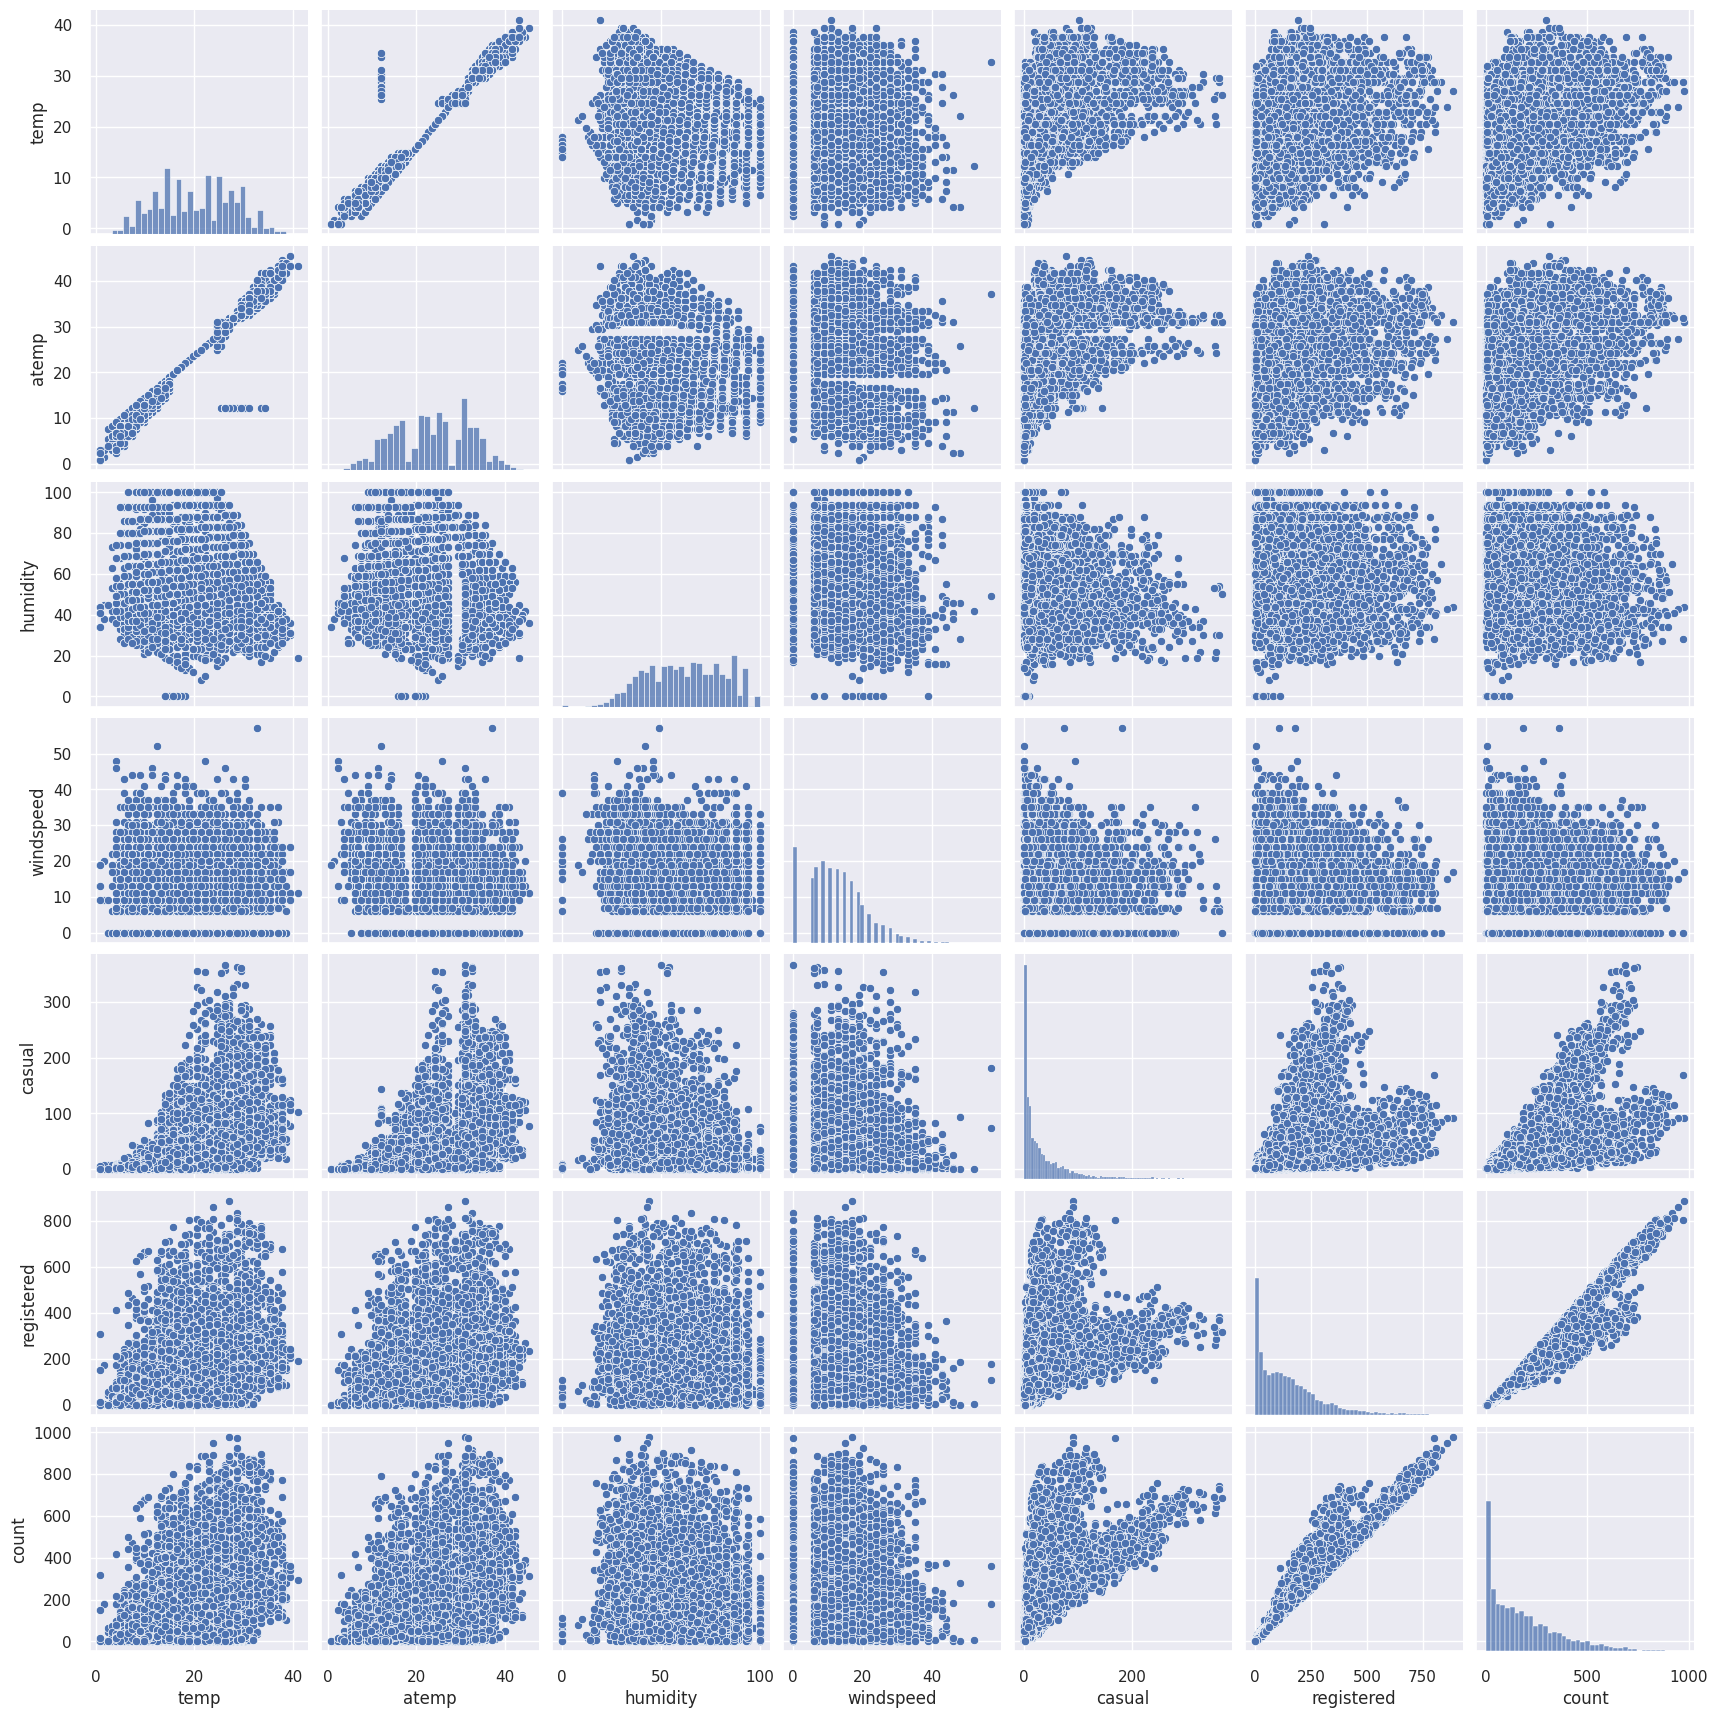

In [8]:
#plot pair plot for the numerical columns
sns.set()
cols = ['temp','atemp','humidity','windspeed','casual',	'registered',	'count']
sns.pairplot(df_analysis_numerical[cols], size = 2.5)
plt.show()

In [9]:
# Correlation matrix for numerical columns
df_analysis_numerical.corr()

,temp,atemp,humidity,windspeed,casual,registered,count
temp,1.000000,0.985248,-0.062023,-0.026653,0.470176,0.323658,0.399809
atemp,0.985248,1.000000,-0.041475,-0.065143,0.465651,0.318756,0.394473
humidity,-0.062023,-0.041475,1.000000,-0.315437,-0.346864,-0.262550,-0.314745
windspeed,-0.026653,-0.065143,-0.315437,1.000000,0.086100,0.084494,0.094212
casual,0.470176,0.465651,-0.346864,0.086100,1.000000,0.498520,0.692298
registered,0.323658,0.318756,-0.262550,0.084494,0.498520,1.000000,0.970674
count,0.399809,0.394473,-0.314745,0.094212,0.692298,0.970674,1.000000


In [10]:
# Helper functions to check the skewness and kurtosis, plot distribution, and check scatter plot between two variables
def skew_check(feature):
  print(feature + " " + "Skewness: %f" % df_analysis[feature].skew())
  print(feature + " " + "Kurtosis: %f" % df_analysis[feature].kurt())

def dist_check(feature):
  plt.figure()
  sns.distplot(df_analysis[feature])

def scatter(df,x,y):
  plt.figure()
  plt.scatter(x=df[x],y=df[y])
  plt.xlabel(x)
  plt.ylabel(y)

In [11]:
for feature in df_analysis_numerical.columns:
  skew_check(feature)

temp Skewness: 0.013199
temp Kurtosis: -0.916627
atemp Skewness: -0.094310
atemp Kurtosis: -0.852575
humidity Skewness: -0.082136
humidity Kurtosis: -0.780005
windspeed Skewness: 0.553033
windspeed Kurtosis: 0.545935
casual Skewness: 2.523789
casual Kurtosis: 7.749940
registered Skewness: 1.515245
registered Kurtosis: 2.580499
count Skewness: 1.239538
count Kurtosis: 1.278276


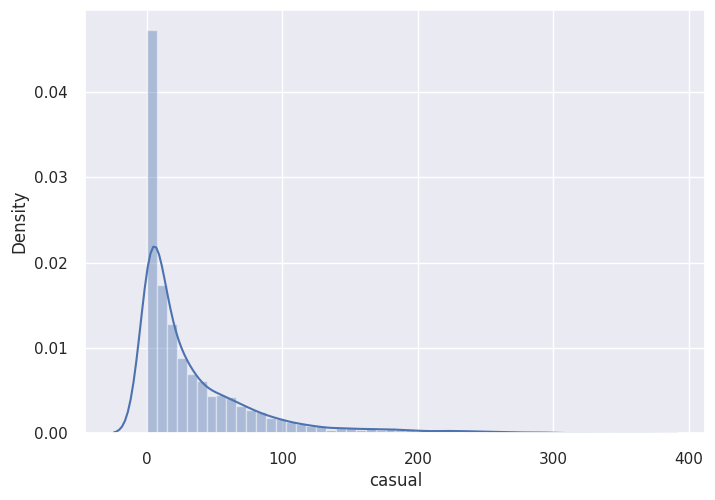

In [12]:
# ditribution of casual
dist_check('casual')

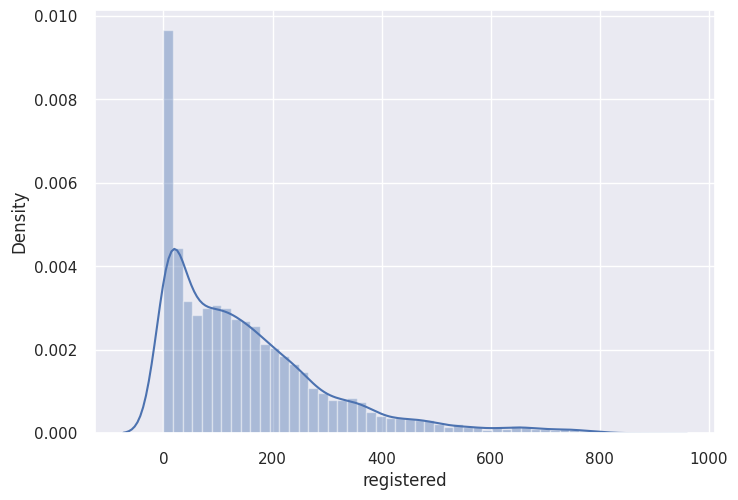

In [13]:
# distribution of registered
dist_check('registered')

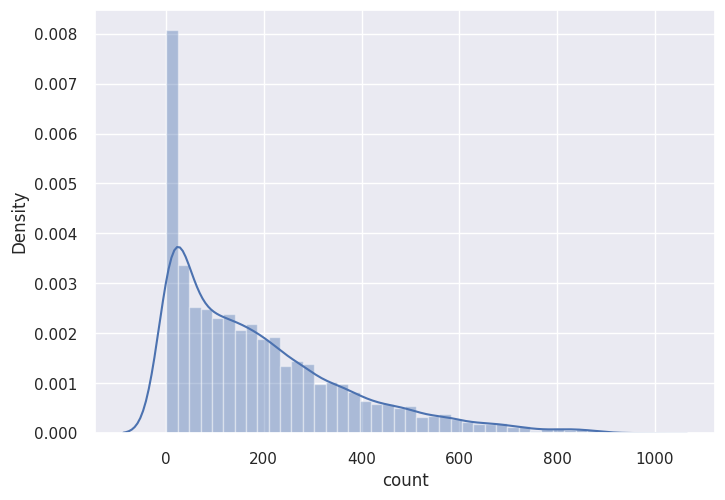

In [14]:
# Distribution of count
dist_check('count')

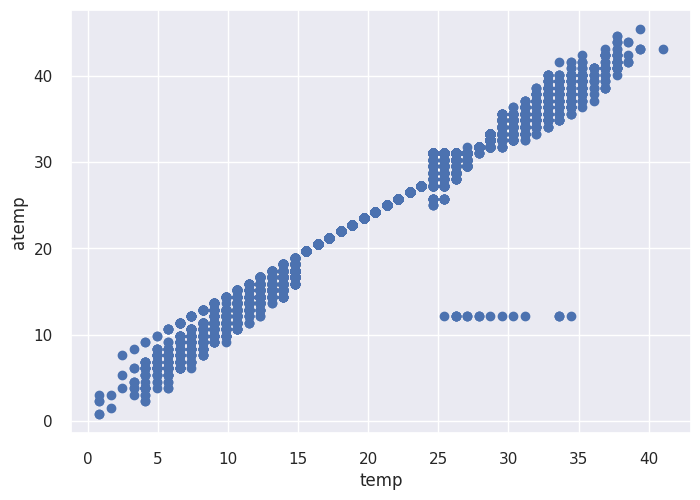

In [15]:
# Plot of temp vs atemp
scatter(df_analysis_numerical,"temp","atemp")

<Axes: ylabel='count'>

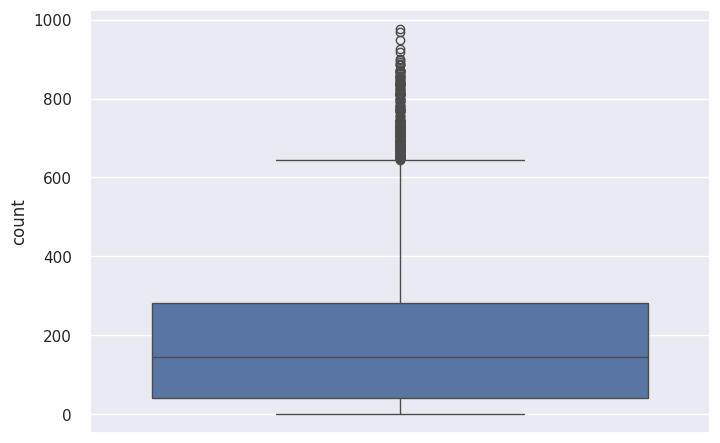

In [16]:
# Box plot of count
sns.boxplot(df_analysis['count'])

<Axes: ylabel='casual'>

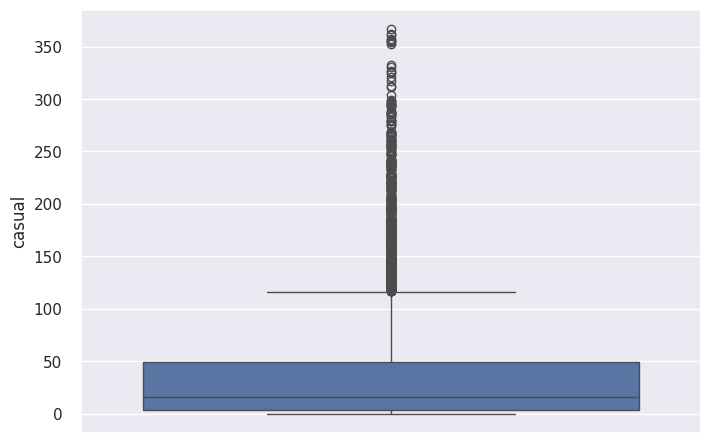

In [17]:
# Box plot of Casual
sns.boxplot(df_analysis['casual'])

<Axes: ylabel='registered'>

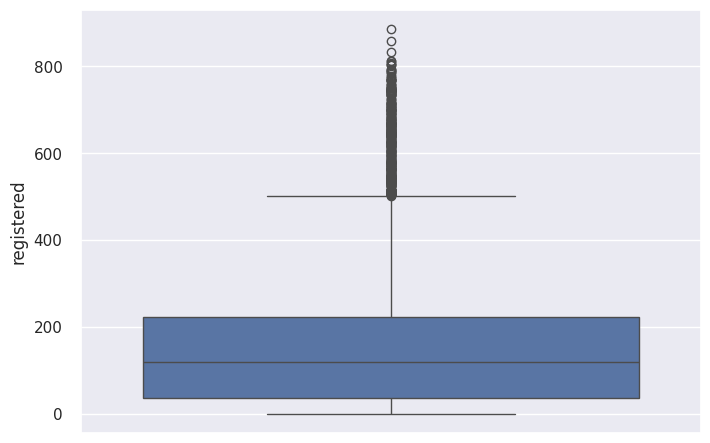

In [18]:
# Box plot of registered
sns.boxplot(df_analysis['registered'])

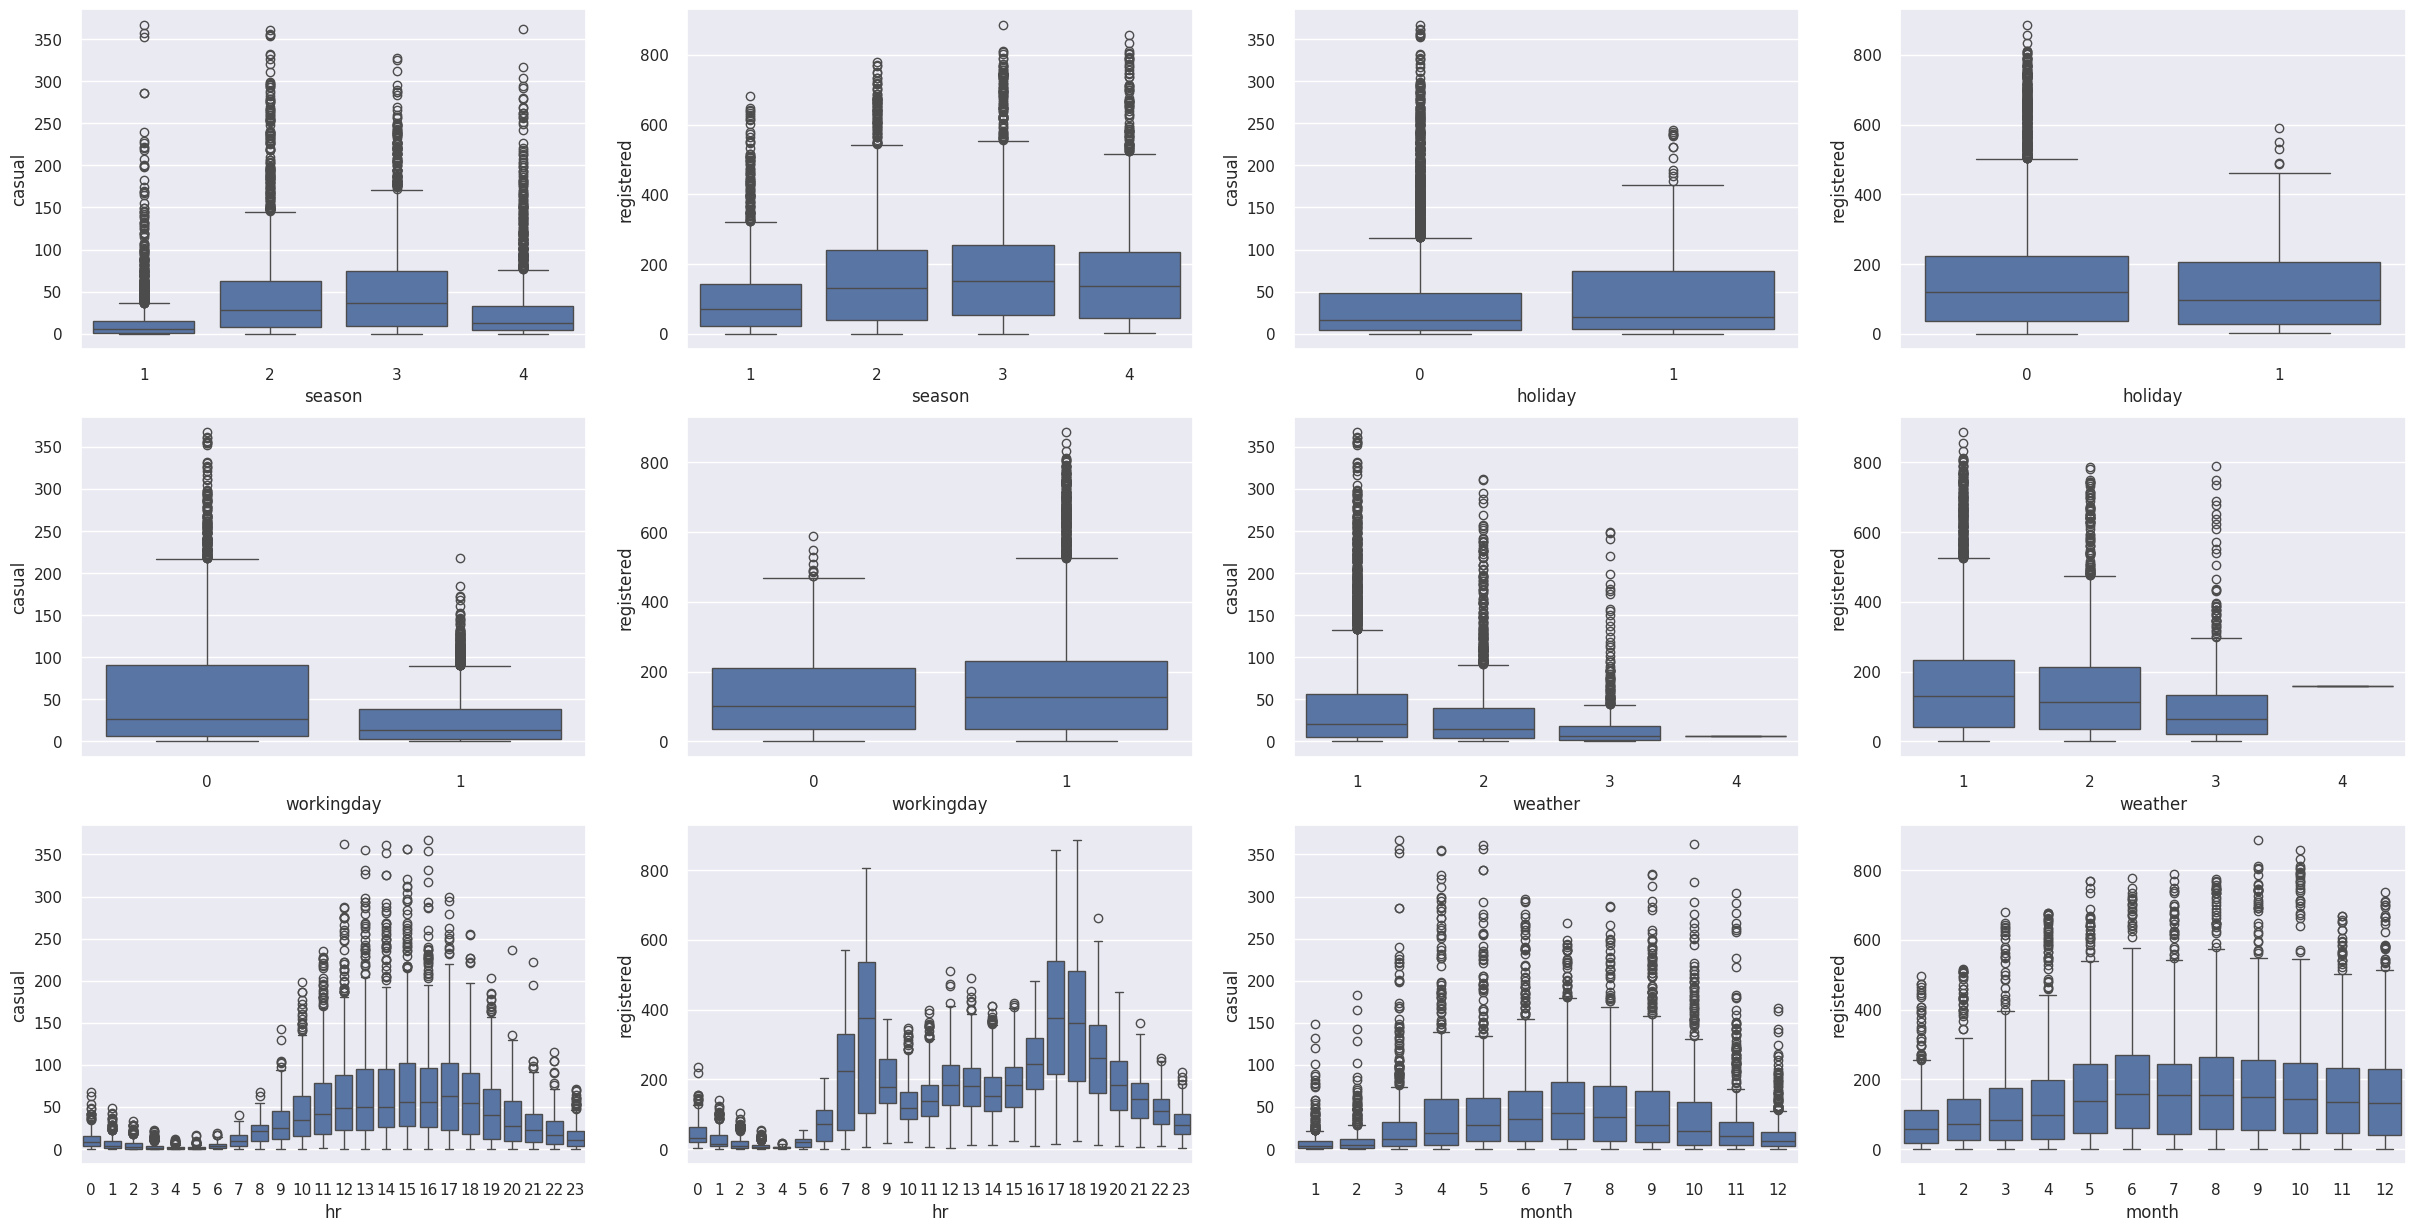

In [19]:
# Box plots of categorical variable vs target varibles (count,casual, and registered)

figure, axis = plt.subplots(3, 4,figsize=(30,15 ))
sns.boxplot(x=df_analysis['season'], y=df_analysis['casual'] , orient='v' , ax=axis[0,0])
sns.boxplot(x=df_analysis['season'], y=df_analysis['registered'], orient='v' , ax=axis[0,1])
sns.boxplot(x=df_analysis['holiday'], y=df_analysis['casual'], orient='v' , ax=axis[0,2])
sns.boxplot(x=df_analysis['holiday'], y=df_analysis['registered'], orient='v' , ax=axis[0,3])
sns.boxplot(x=df_analysis['workingday'], y=df_analysis['casual'], orient='v' , ax=axis[1,0])
sns.boxplot(x=df_analysis['workingday'], y=df_analysis['registered'], orient='v' , ax=axis[1,1])
sns.boxplot(x=df_analysis['weather'], y=df_analysis['casual'], orient='v' , ax=axis[1,2])
sns.boxplot(x=df_analysis['weather'], y=df_analysis['registered'], orient='v' , ax=axis[1,3])
sns.boxplot(x=df_analysis['hr'], y=df_analysis['casual'], orient='v' , ax=axis[2,0])
sns.boxplot(x=df_analysis['hr'], y=df_analysis['registered'], orient='v' , ax=axis[2,1])
sns.boxplot(x=df_analysis['month'], y=df_analysis['casual'], orient='v' , ax=axis[2,2])
sns.boxplot(x=df_analysis['month'], y=df_analysis['registered'], orient='v' , ax=axis[2,3])
plt.show()

## Part 1 — Summary

- **Data completeness:** The training set contains **no missing values**.

- **Correlations (targets = `count`, `registered`, `casual`):**  
  - **Positive:** `temp` and `atemp` increase with demand.  
  - **Negative:** `humidity` decreases as demand increases.  
  - **Near zero:** `windspeed` shows little to no linear relationship with demand.  
  - *Note: correlation ≠ causation—these describe co-movement, not effects.*

- **Collinearity:** `temp` and `atemp` are **highly collinear**. This can introduce **multicollinearity** issues for models sensitive to it (e.g., ordinary least squares). Consider **feature selection** or **regularization** (L1/L2), or use models robust to collinearity (e.g., tree-based).

- **Distributions:** Numeric features (`temp`, `atemp`, `humidity`, `windspeed`) are **non-normal**. For linear methods that assume approximate normality of residuals and homoscedasticity, consider **transformations** (e.g., log/Box-Cox) and/or **feature scaling**.

- **Target variability:** `count`, `registered`, and `casual` show **substantial dispersion and skew/outliers** (as seen in histograms/boxplots), implying a need for **robust evaluation** and possibly **asymmetric loss** if extreme errors are costly.

- **Categorical and time effects:** `season` and `weather` stratify demand meaningfully, and **hour-of-day** shows clear peaks (e.g., elevated demand around **14–18**). These are likely **useful predictors** after proper encoding/feature engineering.

## Part 1 — Data Exploration Summary

### Data completeness and cleaning
The training dataset contains no missing values and no duplicate rows; therefore, neither imputation nor deduplication is required. All column data types are appropriate with the exception of `datetime`, which is cast to a true datetime type. Two time-based features, `hour` (hour of day) and `month`, are extracted from `datetime`. After feature extraction, the raw `datetime` column is removed from the feature set.

### Correlations (targets = `count`, `registered`, `casual`)
A positive linear association is observed between demand and both `temp` and `atemp`. A negative linear association is observed between demand and `humidity`. The variable `windspeed` exhibits little to no linear association with demand. It should be noted that correlation does not imply causation; these results describe co-movement rather than causal effects.

### Collinearity
A high degree of collinearity is present between `temp` and `atemp`, which may introduce multicollinearity for models that are sensitive to such relationships (for example, ordinary least squares). Feature selection methods and regularization techniques (e.g., L1 or L2) could be considered, and model classes that are more robust to collinearity (such as tree-based methods) may be appropriate.

### Distributions
The numeric features `temp`, `atemp`, `humidity`, and `windspeed` display non-normal distributions. For linear methods that rely on approximate normality of residuals and homoscedasticity, data transformations (for example, logarithmic or Box–Cox) and feature scaling may be warranted. In the distributions skewness and kurtosis are also checked.

**Skewness** measures the **asymmetry** of a distribution.
- **Positive skew (> 0):** right tail is longer/heavier (many small values, few very large ones).
- **Negative skew (< 0):** left tail is longer/heavier (many large values, few very small ones).
- **≈ 0:** roughly symmetric.

**Kurtosis** measures **tail weight/peakedness** relative to the Normal.

### Target variability
The target variables `count`, `registered`, and `casual` exhibit substantial dispersion, skewness, and the presence of outliers, as indicated by histograms and boxplots. This behavior suggests that robust evaluation procedures may be beneficial, and that asymmetric loss functions could be appropriate in settings where large errors carry higher costs. Transformations of the target variables (for example, log transformation) may also reduce variability.

### Categorical and time effects
Demand varies meaningfully across the categorical features `season` and `weather`. A pronounced diurnal pattern is also present, with higher demand observed during the late afternoon hours (approximately 14–18). These effects indicate that properly encoded categorical variables and engineered time features are likely to contribute useful predictive signal.

# Part 2: Data transformation

In [20]:
# create a copy of training dataframe for transformation and transform categorical varaibles into encoded values.
df_transform=pd.get_dummies(data=df, columns=['season', 'holiday','workingday','weather','hr','month'])
df_transform.drop(columns=['Unnamed: 0','datetime'],inplace=True)
df_transform.head(2)

,temp,atemp,humidity,windspeed,casual,registered,count,season_1,season_2,season_3,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,25.42,31.06,41,7.0015,63,324,387,False,True,False,...,False,True,False,False,False,False,False,False,False,False
1,29.52,34.85,79,0.0000,158,230,388,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [21]:
# Check if target variables contain 0
df_transform[df_transform.registered==0]

,temp,atemp,humidity,windspeed,casual,registered,count,season_1,season_2,season_3,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
2707,27.06,29.545,89,0.0000,1,0,1,False,False,True,...,False,False,False,False,False,True,False,False,False,False
4236,8.20,7.575,80,35.0008,1,0,1,True,False,False,...,True,False,False,False,False,False,False,False,False,False
5148,15.58,19.695,66,19.0012,1,0,1,False,True,False,...,False,True,False,False,False,False,False,False,False,False
5640,4.92,6.060,50,19.0012,1,0,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False
6508,9.02,13.635,80,0.0000,2,0,2,True,False,False,...,False,False,False,False,False,False,False,False,False,False
6832,22.96,26.515,88,0.0000,2,0,2,False,False,True,...,False,False,False,False,False,False,True,False,False,False
7328,24.60,28.790,78,0.0000,2,0,2,False,False,True,...,False,False,False,False,False,False,True,False,False,False
7968,7.38,9.090,74,12.9980,1,0,1,True,False,False,...,True,False,False,False,False,False,False,False,False,False
8014,18.04,21.970,77,15.0013,1,0,1,False,False,True,...,False,False,False,False,False,False,True,False,False,False
8666,8.20,10.605,75,8.9981,1,0,1,True,False,False,...,True,False,False,False,False,False,False,False,False,False


Skewness: 0.123653
Kurtosis: -0.616341


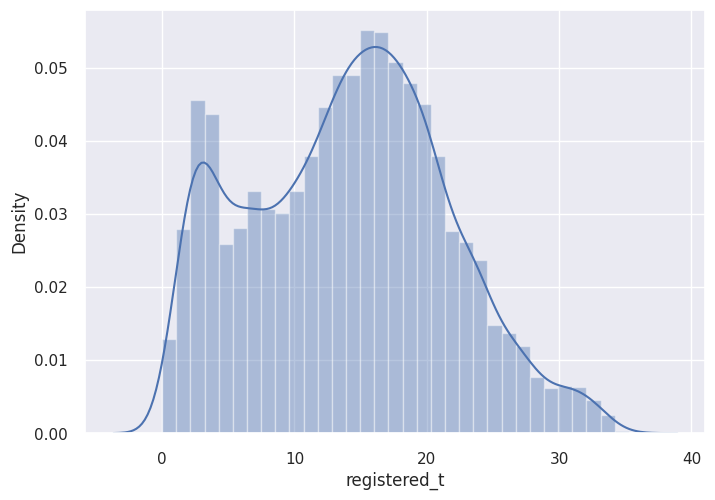

In [22]:
# transform the target variable registered due to variability
df_transform['registered_t']=boxcox1p(df_transform['registered'],0.4)
sns.distplot(df_transform['registered_t'])
print("Skewness: %f" % df_transform['registered_t'].skew())
print("Kurtosis: %f" % df_transform['registered_t'].kurt())

Skewness: 0.541784
Kurtosis: -0.349178


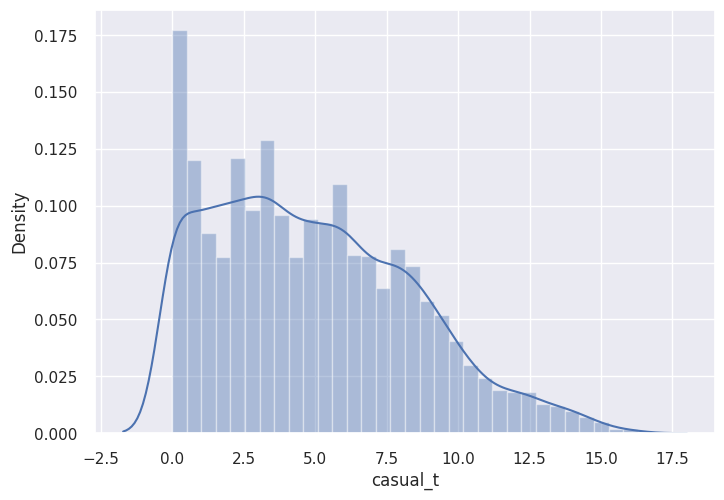

In [23]:
# transform the target variable casual due to variability
df_transform['casual_t']=boxcox1p(df_transform['casual'],0.3)
sns.distplot(df_transform['casual_t'])
print("Skewness: %f" % df_transform['casual_t'].skew())
print("Kurtosis: %f" % df_transform['casual_t'].kurt())

Skewness: 0.066905
Kurtosis: -0.820554


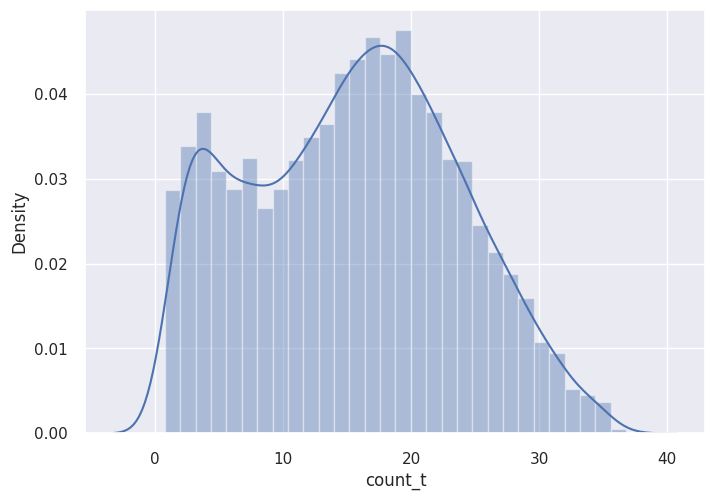

In [24]:
# transform the target variable casual due to variability
df_transform['count_t']=boxcox1p(df_transform['count'],0.4)
sns.distplot(df_transform['count_t'])
print("Skewness: %f" % df_transform['count_t'].skew())
print("Kurtosis: %f" % df_transform['count_t'].kurt())

# Part 2 Summary

### Categorical Feature Transformation: Why and how `pd.get_dummies` is used

Most machine-learning algorithms operate on **numeric** inputs and do not inherently understand categorical labels. Feeding raw category labels (strings or arbitrary integers) can:
- Implicitly introduce a **fake ordering** (e.g., encoding Winter=1, Spring=2, … suggests distances that do not exist), which can distort linear models and distance-based methods.
- Conflate multiple effects into one coefficient and hinder interpretability in linear models.

To address this, the categorical variables **`season`**, **`holiday`**, **`workingday`**, **`weather`**, and the engineered time features **`hr`** (hour of day) and **`month`** are **one-hot encoded** using `pd.get_dummies`. One-hot encoding creates **binary indicator columns**—one per category—so that the model can learn a separate weight (or split) for each category without imposing any artificial ordinality.

**What `pd.get_dummies` does:**
- Scans a column’s unique categories and creates a new column for each category (e.g., `season_1`, `season_2`, `season_3`, `season_4`).
- Sets the indicator to **1** if the row belongs to that category and **0** otherwise.
- Can optionally drop one column per set (with `drop_first=True`) to avoid perfect multicollinearity in linear models; when using tree-based models this is typically not required, but keeping a consistent design across models can be beneficial.

**Why this helps across model classes:**
- **Linear / GLM-type models:** One-hot encoding prevents spurious ordering and lets each category have its own effect.
- **Tree-based models (e.g., Random Forests):** While trees can split on integer-coded categories, arbitrary integer labels still impose a numeric ordering that can bias split search. One-hot encoding avoids this and allows trees to consider category membership directly.

**Implementation notes:**
- The same dummy columns must exist in both **train** and **test** sets. After fitting on train, align test columns (adding any missing dummies with zeros).
- High-cardinality features (not present here) may require alternative encoders (e.g., target encoding), but standard one-hot encoding is appropriate for `season`, `holiday`, `workingday`, `weather`, `hr`, and `month`.

---
### Numerical Features: Scaling plan and data-leakage avoidance

At this stage, the numeric predictors (`temp`, `atemp`, `humidity`, `windspeed`, and any other continuous features) are **not transformed yet**. These features will be scaled using a **Min–Max Scaler** **inside the modeling pipeline** (i.e., fitted on the training folds only and applied to validation/test via the same fitted transformer). Deferring scaling to the pipeline prevents **data leakage**, a situation where information from the validation/test set inadvertently influences preprocessing steps (for example, by using global minima/maxima from the full dataset), leading to optimistically biased performance estimates. The leakage concept and the full pipeline implementation will be explained in the modeling section.

---
### Target Transformation: Why Box–Cox (`boxcox1p`) instead of a plain log

The target variables (`count`, `registered`, `casual`) exhibit high variability, skewness, and outliers. Such characteristics can lead to heteroscedastic residuals and make squared-error losses (MSE/RMSE) overly sensitive to extreme values. A variance-stabilizing, monotonic transformation reduces skew, dampens the influence of outliers, and can reveal more linear signal for models that benefit from it.

A simple log transform is a natural idea; however, the presence of **zeros** in the targets makes `log(y)` undefined. While `log1p(y)` can handle zeros, **Box–Cox** offers a more flexible, one-parameter family that **includes** `log1p` as a special case and lets the data determine the strength of tail compression:


boxcox1p(y,{\lambda})=
\begin{cases}
\frac{(1+y)^\lambda - 1}{\lambda}, & \lambda \neq 0 \\
\log(1+y), & \lambda = 0
\end{cases}


In this project, `boxcox1p` with **λ = 0.4** applies **moderate compression** (stronger than identity, gentler than log). This choice preserves ordering, reduces heteroscedasticity, and often yields more stable fitting under squared-error losses. Although tree-based regressors (e.g., **Random Forests**, Gradient Boosted Trees) do not require normality or linearity and are relatively robust to monotonic **feature** transforms, a **target** transformation can still help because trees minimize squared error **on the transformed target scale** during training; stabilizing variance reduces the leverage of extreme targets, can lead to more balanced splits, and can lower RMSE after inverting the transform. Here, λ = 0.4 and 0.3 for casual is used as a reasonable starting point based on trying different values and visually inspecting the corresponding distribution. However lambda can be treated as a **hyperparameter** for later tuning via cross-validation. λ is chosen on the training set and held fixed; predictions are mapped back with the inverse transform so metrics are reported in original units.













# Part 3: Modeling

## Modeling Design Considerations

Effective modeling design depends on **how the model will be used**. In this project, the model’s purpose is **interpolation** (filling missing historical targets), not **forecasting** (predicting future demand). This distinction drives the validation strategy and what constitutes data leakage.

### If this were demand forecasting
- **Inference reality:** At prediction time, **future targets are unknown** and future feature values may also be unknown or only partially known.
- **Implication for training/validation:** The training/validation split must **respect time order** so the model never “sees” the future while learning to predict the past.
- **Recommended CV:** Use **time-based (blocked) cross-validation** (e.g., rolling or expanding window). Training must be restricted to **past** data; validation must occur on strictly **later** time periods.
- **Risk if ignored:** Random K-Fold would leak future information into training, yielding **over-optimistic** estimates and unstable production behavior.

### For this project’s use case (interpolation)
- **Inference reality:** The task is to fill **missing targets within the historical period** where the **feature values at those timestamps are known** (e.g., hour, month, weather recorded for that hour).
- **Information usage:** Because the goal is not to predict unseen future periods, it is acceptable for the model to learn from **both earlier and later timestamps** relative to a missing entry, as long as it does **not** use the missing **target** itself.
- **Validation choice:** Standard **K-Fold cross-validation** is acceptable, since at “inference” time the model will also rely on features available at the same timestamps.  
  - Exception: if features include **leaky constructs** (e.g., rolling means computed using future values), those must be engineered with **causal windows** to avoid target leakage—even for interpolation.
- **Key constraint:** Avoid any transformation that incorporates the **missing targets** or aggregates that implicitly **peek at targets** from the validation folds (e.g., target encoding fit on all data).

### Summary
- **Forecasting:** enforce **time-aware splits** to prevent future→past leakage.  
- **Interpolation (this project):** **non-time-aware CV** is suitable because inference also occurs **within** the historical window and uses features known at those times. Still, apply standard anti-leakage practices (fit scalers/encoders only on training folds; avoid target-derived features; use causal windows for any temporal aggregations).




## 3.1: Baseline Modeling

In [25]:
# Define target variables and split features (X) from targets (y) for modeling.
# Note: *_t columns are transformed versions of the targets.
target_cls = ['casual', 'registered', 'count', 'casual_t', 'registered_t', 'count_t']
X, y = df_transform.drop(columns=target_cls), df_transform[target_cls]


def cross_validation(model, _X, _y, _cv, tar_cols):
    """
    Perform K-Fold cross-validation for a single (feature) model across multiple target columns.

    Parameters
    ----------
    model : estimator
        Any sklearn-like regressor implementing .fit(X, y) and .predict(X).
    _X : pd.DataFrame
        Feature matrix (unscaled / pre-encoding as applicable).
    _y : pd.DataFrame
        DataFrame containing the target columns listed in `tar_cols`.
    _cv : int
        Number of K-Fold splits.
    tar_cols : list[str]
        Target column names to iterate over (e.g., ['casual_t', 'registered_t', 'count_t']).

    Returns
    -------
    res_scores : list[dict]
        Per-fold metrics for each target column.
    fold_coord : list[tuple]
        List of (train_index, test_index) tuples for each fold (for traceability).
    """

    # Continuous features to scale. These will be scaled INSIDE each fold to avoid data leakage.
    features_need_to_standardize = ['temp', 'atemp', 'humidity', 'windspeed']


    _scoring = ['r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error']

    res_scores = []


    kf = KFold(n_splits=_cv)

    fold_coord = []
    for train_index, test_index in kf.split(_X, _y):


        training_data = _X.iloc[train_index].copy()
        validation_data = _X.iloc[test_index].copy()
        fold_coord.append((train_index, test_index))

        # Fit MinMaxScaler on TRAINING data only; apply same transform to VALIDATION.
        # This is the correct pattern to prevent leakage.
        scaler = MinMaxScaler()
        training_data[features_need_to_standardize] = scaler.fit_transform(
            training_data[features_need_to_standardize]
        )
        validation_data[features_need_to_standardize] = scaler.transform(
            validation_data[features_need_to_standardize]
        )

        # Fit and evaluate the provided model for each target column independently.
        for tar in tar_cols:
            # Slice labels for this target and the current fold.
            training_label = _y[[tar]].iloc[train_index]
            validation_label = _y[[tar]].iloc[test_index]

            model.fit(training_data, training_label)
            validation_predict = model.predict(validation_data)
            training_predict = model.predict(training_data)


            res_scores.append({
                "Training R2": r2_score(training_label, training_predict),
                "Training _mean_squared_error": mean_squared_error(training_label, training_predict),
                "Training _root_mean_squared_error": np.sqrt(
                    mean_squared_error(training_label, training_predict)
                ),
                "Testing R2": r2_score(validation_label, validation_predict),
                "Testing _mean_squared_error": mean_squared_error(validation_label, validation_predict),
                "Testing _root_mean_squared_error": np.sqrt(
                    mean_squared_error(validation_label, validation_predict)
                ),
                "type_of_model": tar
            })

    return res_scores, fold_coord


# Grouped Bar Chart for both training and validation data
def plot_result(x_label, y_label, plot_title, train_data, val_data):
    """
    Plot side-by-side bars for training vs. validation across CV folds.

    Parameters
    ----------
    x_label : str
        Label for x-axis.
    y_label : str
        Label for y-axis.
    plot_title : str
        Title of the plot.
    train_data : list[float] or np.ndarray
        Metric values for training per fold (length should equal number of folds).
    val_data : list[float] or np.ndarray
        Metric values for validation per fold (length should equal number of folds).
    """
    plt.figure(figsize=(12, 6))

    n = len(train_data)
    labels = [f"{i+1}st Fold" if i == 0 else
              f"{i+1}nd Fold" if i == 1 else
              f"{i+1}rd Fold" if i == 2 else
              f"{i+1}th Fold" for i in range(n)]

    X_axis = np.arange(len(labels))
    ax = plt.gca()


    plt.ylim(-1, 1)

    # Bars for training vs validation
    plt.bar(X_axis - 0.2, train_data, label='Training')
    plt.bar(X_axis + 0.2, val_data, label='Validation')

    plt.title(plot_title, fontsize=18)
    plt.xticks(X_axis, labels)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [26]:
# Targets to model (Box–Cox–transformed versions of the original targets)
tar_cols = ['casual_t', 'registered_t', 'count_t']

# Instantiate a plain Ordinary Least Squares regressor from sklearn
Lm = LinearRegression()

# Run the custom K-Fold CV routine defined earlier:
# - Uses X as features and y as a DataFrame containing all targets
# - Performs 5-fold CV
# - Trains and evaluates the same model separately for each target in tar_cols
Lr_result, fold_cord = cross_validation(Lm, X, y, 5, tar_cols)

# Convert the list of per-fold metric dicts returned by cross_validation into a DataFrame
Lr_result = pd.DataFrame(Lr_result)

In [27]:
Lr_result

,Training R2,Training _mean_squared_error,Training _root_mean_squared_error,Testing R2,Testing _mean_squared_error,Testing _root_mean_squared_error,type_of_model
0,0.798706,2.504129,1.582444,0.781288,2.661592,1.631439,casual_t
1,0.750819,13.973500,3.738114,0.761627,13.500389,3.674288,registered_t
2,0.766219,15.691322,3.961227,0.772383,15.342335,3.916929,count_t
3,0.796085,2.518687,1.587037,0.792358,2.600657,1.612655,casual_t
4,0.753668,13.827566,3.718544,0.750038,14.102370,3.755312,registered_t
5,0.768033,15.562834,3.944976,0.765280,15.854838,3.981813,count_t
6,0.797033,2.533630,1.591738,0.788402,2.540056,1.593755,casual_t
7,0.755471,13.790612,3.713571,0.743084,14.228017,3.772004,registered_t
8,0.770533,15.484512,3.935036,0.755243,16.152546,4.019023,count_t
9,0.792911,2.530592,1.590783,0.804395,2.553692,1.598027,casual_t


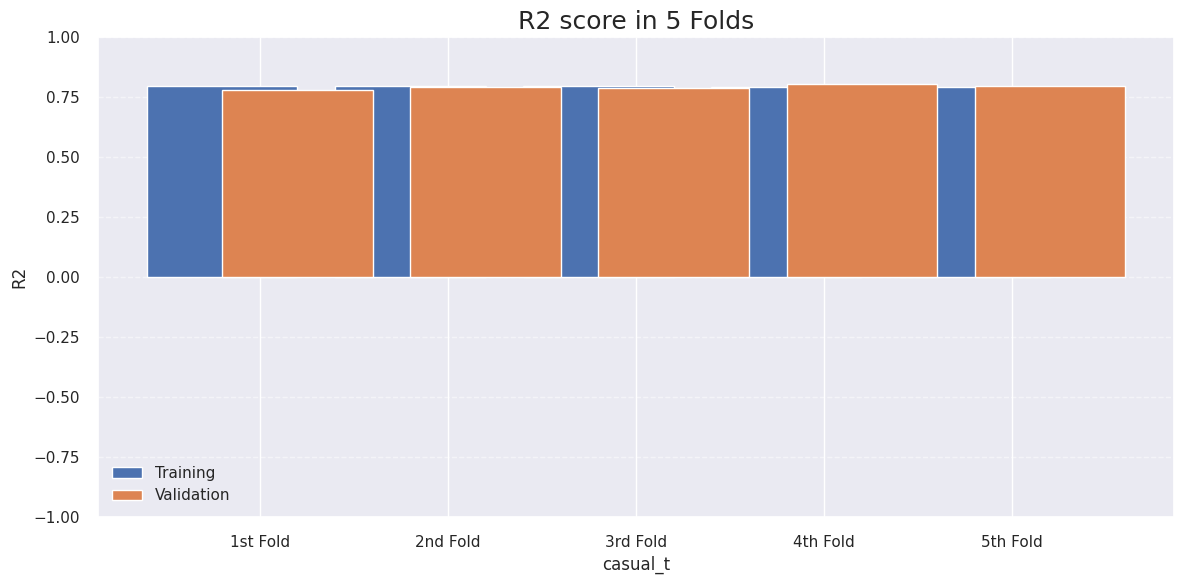

In [28]:
# Select which target’s CV results to visualize (here: Box–Cox–transformed 'casual')
model_name = "casual_t"

# Filter the aggregated CV results to rows corresponding to this target
Lr_casual_result = Lr_result[Lr_result['type_of_model'] == model_name]

# Plot training vs. validation (testing) R² across the 5 folds.
# - x_label: shown on the x-axis (here we use the target name)
# - y_label: metric being plotted ("R2")
# - plot_title: title for the chart
# - train_data / val_data: sequences of per-fold scores (length should equal #folds)
plot_result(
    model_name,
    "R2",
    "R2 score in 5 Folds",
    Lr_casual_result["Training R2"],
    Lr_casual_result["Testing R2"],
)

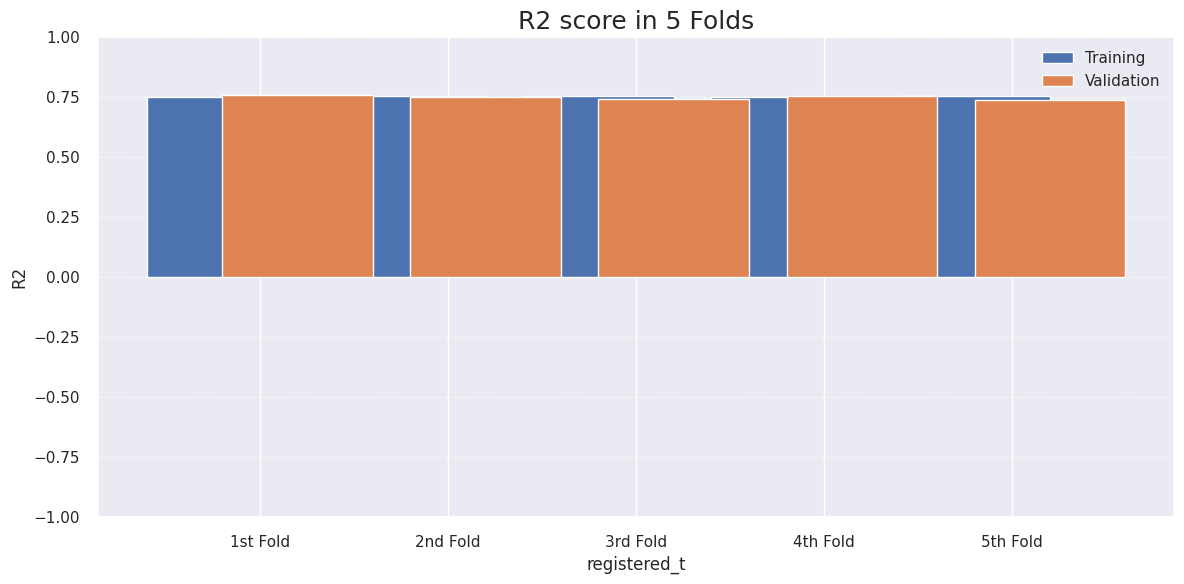

In [29]:
model_name = "registered_t"
Lr_register_result=Lr_result[Lr_result['type_of_model']==model_name]
plot_result(model_name,
            "R2",
            "R2 score in 5 Folds",
            Lr_register_result["Training R2"],Lr_register_result["Testing R2"])

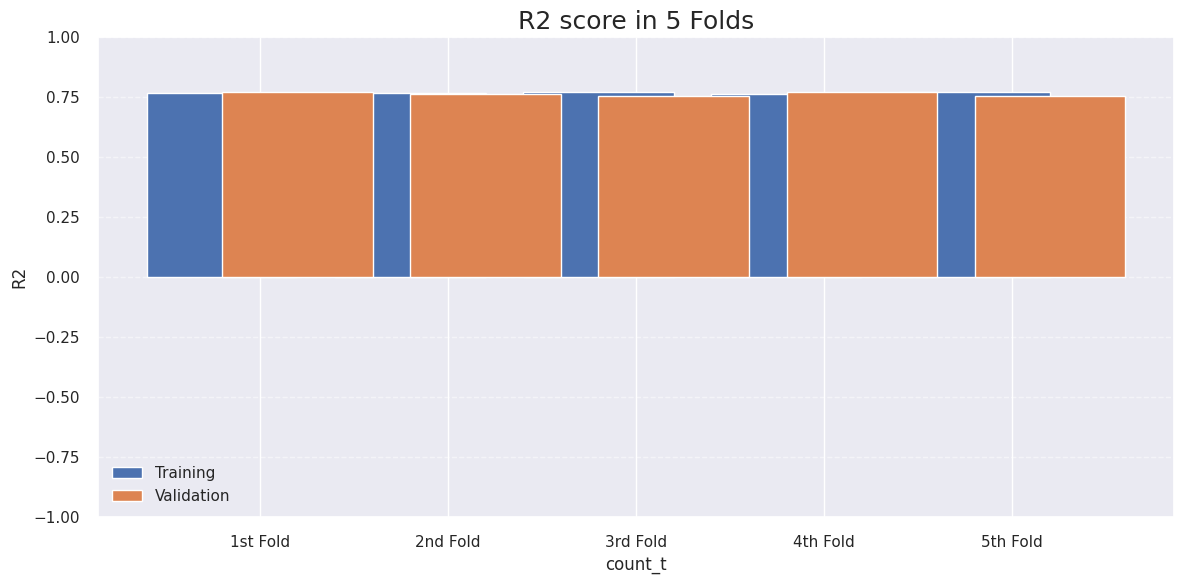

In [30]:
model_name = "count_t"
Lr_count_result=Lr_result[Lr_result['type_of_model']==model_name]
plot_result(model_name,
            "R2",
            "R2 score in 5 Folds",
            Lr_count_result["Training R2"],Lr_count_result["Testing R2"])

In [31]:
Rr = RandomForestRegressor()

# Run the previously defined K-Fold cross-validation routine:
# - Uses X as features and y as a DataFrame containing all targets
# - Performs 5-fold CV
# - Trains/evaluates the SAME RF model separately for each target in tar_cols
# - Returns a list of per-fold metric dicts and the fold indices for traceability
Rr_result, fold_cord = cross_validation(Rr, X, y, 5, tar_cols)

# Convert the results list into a tidy DataFrame for analysis/plotting
Rr_result = pd.DataFrame(Rr_result)

In [32]:
Rr_result

,Training R2,Training _mean_squared_error,Training _root_mean_squared_error,Testing R2,Testing _mean_squared_error,Testing _root_mean_squared_error,type_of_model
0,0.981230,0.233503,0.483221,0.860478,1.697901,1.303035,casual_t
1,0.984297,0.880563,0.938383,0.892287,6.100352,2.469889,registered_t
2,0.984220,1.059164,1.029157,0.889162,7.470951,2.733304,count_t
3,0.980350,0.242712,0.492658,0.876059,1.552327,1.245924,casual_t
4,0.984211,0.886326,0.941449,0.887447,6.350026,2.519926,registered_t
5,0.984135,1.064361,1.031679,0.891662,7.317960,2.705173,count_t
6,0.980203,0.247130,0.497122,0.858595,1.697451,1.302863,casual_t
7,0.984522,0.872898,0.934290,0.886094,6.308104,2.511594,registered_t
8,0.983899,1.086468,1.042338,0.885166,7.578405,2.752890,count_t
9,0.980139,0.242693,0.492639,0.855020,1.892765,1.375778,casual_t


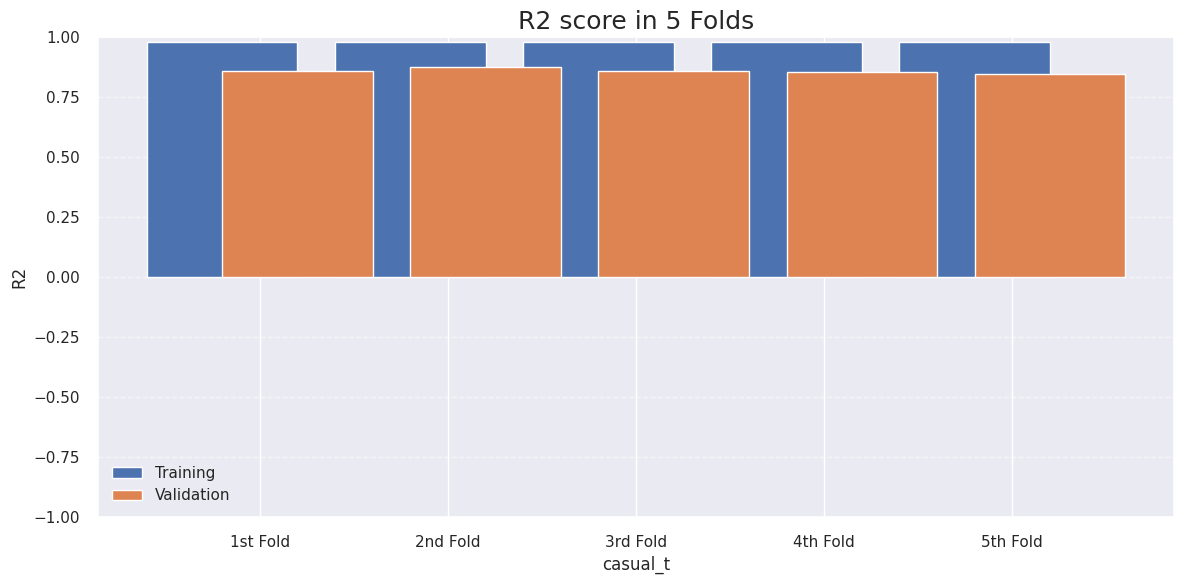

In [33]:
model_name = "casual_t"
Rr_casual_result=Rr_result[Rr_result['type_of_model']==model_name]
plot_result(model_name,
            "R2",
            "R2 score in 5 Folds",
            Rr_casual_result["Training R2"],Rr_casual_result["Testing R2"])

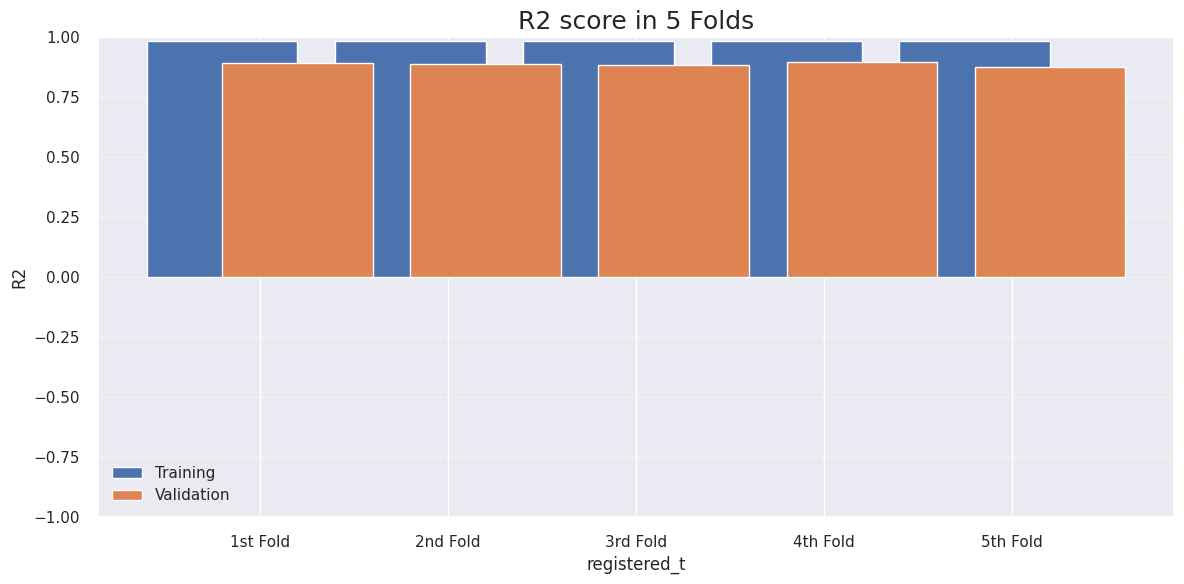

In [34]:
model_name = "registered_t"
Rr_registered_result=Rr_result[Rr_result['type_of_model']==model_name]
plot_result(model_name,
            "R2",
            "R2 score in 5 Folds",
            Rr_registered_result["Training R2"],Rr_registered_result["Testing R2"])

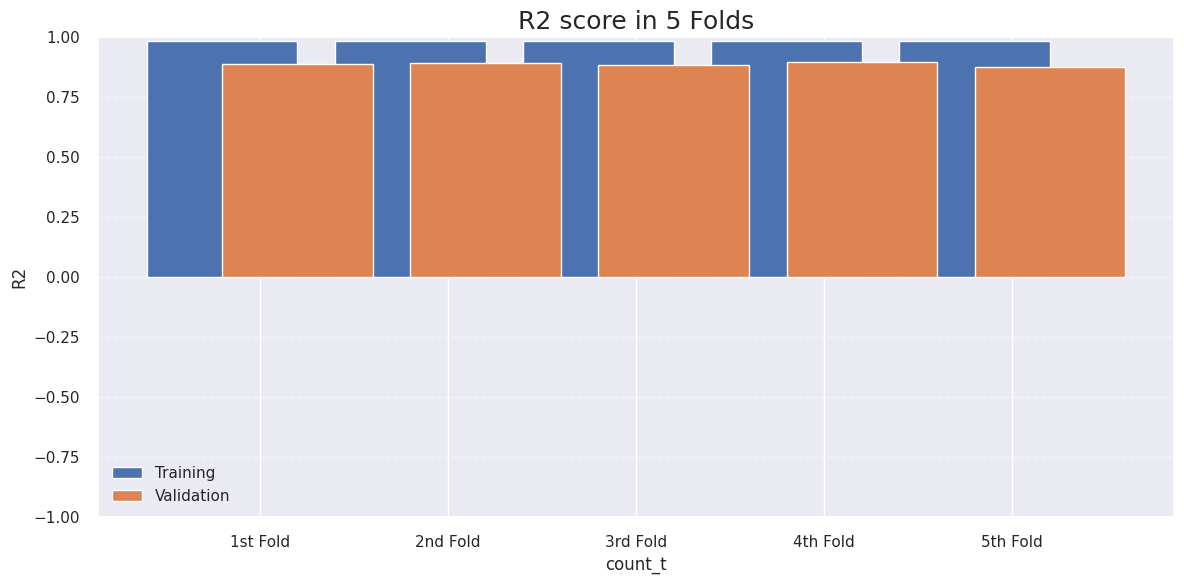

In [35]:
model_name = "count_t"
Rr_count_result=Rr_result[Rr_result['type_of_model']==model_name]
plot_result(model_name,
            "R2",
            "R2 score in 5 Folds",
            Rr_count_result["Training R2"],Rr_count_result["Testing R2"])

In [36]:
Xr= XGBRegressor()
Xr_result,fold_cord = cross_validation(Xr, X, y, 5,tar_cols)
Xr_result=pd.DataFrame(Xr_result)

In [37]:
Xr_result

,Training R2,Training _mean_squared_error,Training _root_mean_squared_error,Testing R2,Testing _mean_squared_error,Testing _root_mean_squared_error,type_of_model
0,0.956911,0.536031,0.732142,0.868047,1.605789,1.267197,casual_t
1,0.962010,2.130366,1.459577,0.897599,5.799511,2.408217,registered_t
2,0.965383,2.323486,1.524298,0.901194,6.659960,2.580690,count_t
3,0.956812,0.533447,0.730375,0.881187,1.488099,1.219877,casual_t
4,0.962445,2.108131,1.451940,0.890533,6.175881,2.485132,registered_t
5,0.963398,2.455675,1.567059,0.898710,6.841882,2.615699,count_t
6,0.956527,0.542670,0.736661,0.875635,1.492903,1.221844,casual_t
7,0.960749,2.213624,1.487825,0.894719,5.830472,2.414637,registered_t
8,0.963728,2.447656,1.564499,0.899483,6.633521,2.575562,count_t
9,0.955850,0.539499,0.734506,0.876616,1.610820,1.269181,casual_t


## Basline Modeling summary

### Models evaluated
Three baseline regressors were trained and compared:
1. **Linear Regression (OLS)** — a linear model.
2. **RandomForestRegressor (RF)** — a non-linear, **bagging** ensemble of decision trees.
3. **XGBRegressor (XGBoost)** — a non-linear, **boosting** ensemble of decision trees.

All three models were trained to predict the Box–Cox–transformed targets (`*_t`). A **5-fold cross-validation** procedure was used to estimate generalization.

### Loss functions and evaluation metric
- **Tree-based training loss:**  
  - For Random Forest, the split criterion was **squared error** (MSE) at each node, which aligns with the problem’s emphasis on penalizing large errors more heavily.
  - For XGBoost, the objective was set to the squared-error family (minimizing MSE/RMSE), likewise emphasizing larger mistakes.
- **Reported metric:** RMSE and R^2 was used for model comparison. RMSE is simply the square root of MSE and is therefore in the **same units as the target**, which makes error magnitudes easier to interpret in a business context than raw MSE.

### Preprocessing notes (baseline)
- **Target transformation:** Targets were transformed with **`boxcox1p` (λ = 0.4)** to reduce skew and stabilize variance (details in the EDA/transform section).
- **Feature scaling:** For this baseline, a **Min–Max Scaler** was applied *inside the CV folds* to avoid leakage.  
  - **Linear Regression:** require feature normalization for correctness, but scaling can improve numerical stability and is important when regularization is introduced later.  
  - **Tree-based models (RF, XGB):** do **not** require feature scaling or normal distributions for correctness (splits depend on orderings and thresholds, not distances). Scaling rarely changes their predictions materially; it is included here mainly to keep the preprocessing pipeline consistent across models.

> Clarification: while linear methods often benefit from transforming features to better satisfy assumptions about **residuals** (e.g., homoscedasticity), tree ensembles are generally robust to skewed/heteroscedastic features. Target transformation can still help trees by reducing the leverage of extreme target values under squared-error losses.

### Results at a glance
- All three models achieved **meaningful lift** over a naïve baseline (R² > 0 across folds).
- **Random Forest and XGBoost** delivered **lower validation RMSE / higher validation R²** than Linear Regression on average.
- **Overfitting signal:** RF and XGB showed a **gap** between training and validation scores (train markedly better than validation), typical for high-capacity non-linear ensembles at default settings. Linear Regression exhibited **similar training and validation performance** across folds, indicating lower variance but also lower peak accuracy.
- **Stability across folds:** Scores were broadly consistent across the 5 folds for all models, suggesting the CV estimate is reliable.

### Model choice for the baseline
Given (i) stronger validation performance from the **non-linear** methods and (ii) substantial collinearity among features (e.g., `temp` vs `atemp`), the baseline model selected is **RandomForestRegressor**. In our runs, RF and XGB performed similarly on validation data; **RF** was chosen for the baseline because it is **simpler to configure**, **faster to iterate**, and more **interpretable** at the feature-importance and partial-dependence level without extensive parameter tuning.

### Next steps
The next section will:
- Perform **feature selection/regularization** (to reduce variance and address collinearity for linear baselines).
- Run **hyperparameter optimization**.


## Part 3.2: Model optimization - feature selection and hyperparameter optimization

In [51]:
# Split features and targets into train/test sets.
# - Features: all columns except targets in `target_cls`
# - Targets: all columns listed in `target_cls` (e.g., ['casual', 'registered', 'count', ...])
# - test_size=0.15 reserves 15% for testing; random_state ensures reproducibility.
x_train, x_test, y_train, y_test = train_test_split(
    df_transform.drop(columns=target_cls),
    df_transform[target_cls],
    test_size=0.15,
    random_state=42
)


def feature_imp_def_rf(reg_tree, X_test, y_test):
    """
    Compute permutation feature importances for a fitted tree/forest model.

    Parameters
    ----------
    reg_tree : fitted estimator
        A trained regressor (e.g., RandomForestRegressor) that supports .predict().
    X_test : pd.DataFrame
        Test features. Must have the same columns and preprocessing as the model expects.
    y_test : pd.Series or 1D array-like
        Test target corresponding to the specific model you are analyzing.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns:
        - 'imp_score': mean decrease in score when each feature is permuted
        - 'labels'   : feature names
        (Higher 'imp_score' implies greater importance under the chosen scoring.)
    """

    # Use the column names directly from X_test to label importances.
    feature_names = list(X_test.columns)

    # Permutation importance:
    # - n_repeats: number of shuffles per feature (more → stabler estimates, slower)
    # - random_state: reproducible permutations
    # - n_jobs: parallelism (set to -1 to use all cores)
    result = permutation_importance(
        reg_tree,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=2, scoring='neg_mean_squared_error'
    )

    forest_importances = pd.DataFrame({
        'imp_score': result.importances_mean,
        'labels': feature_names
    })

    return forest_importances

In [52]:
def model_fit_rf(x_train, x_test, y_train, y_test, model, tar_cols):
    """
    Fit a (tree-based) model per target, perform simple permutation-importance-based
    feature selection, refit on the selected features, and report metrics.

    Parameters
    ----------
    x_train, x_test : pd.DataFrame
        Train/test feature matrices (already split). NOTE: This function scales
        a few numeric columns; see comments below about copies to avoid re-scaling drift.
    y_train, y_test : pd.DataFrame
        Train/test targets. Must contain the columns listed in `tar_cols`.
    model : estimator
        An sklearn regressor (e.g., RandomForestRegressor) with .fit/.predict.
    tar_cols : list[str]
        Target column names to loop over (e.g., ['casual_t','registered_t','count_t']).

    Returns
    -------
    (pd.DataFrame, dict[str, pd.DataFrame], dict[str, list[str]])
        - metrics DataFrame (one row per target),
        - dict of permutation-importance DataFrames keyed by target,
        - dict of selected-feature lists keyed by target.
    """

    res_scores = []        # will collect per-target metric dicts
    f_imp_s = {}           # will store permutation-importance tables per target
    selected_features = {} # will store selected-feature names per target

    for tar in tar_cols:
        # Columns slated for scaling. For RF/XGB this isn't required for correctness,
        # but included for consistent pipeline across models.
        features_need_to_standardize = ['temp', 'atemp', 'humidity', 'windspeed']

        Xtr = x_train.copy()
        Xte = x_test.copy()

        # Fit scaler on TRAIN ONLY, then apply to TEST (prevents leakage).
        scaler = MinMaxScaler()
        Xtr[features_need_to_standardize] = scaler.fit_transform(
            Xtr[features_need_to_standardize]
        )
        Xte[features_need_to_standardize] = scaler.transform(
            Xte[features_need_to_standardize]
        )

        # Fit the base model on ALL features for this specific target.
        reg = model.fit(Xtr, y_train[[tar]])

        # Determine the set of feature labels (targets already excluded upstream).
        feat_labels = list(Xtr.columns)

        print(tar)

        # Compute permutation importance on the TEST set.
        f_imp = feature_imp_def_rf(reg, Xte, y_test[tar])
        f_imp_s[tar] = f_imp

        # Sort by mean importance descending
        f_imp.sort_values(by=['imp_score'], ascending=False, inplace=True)

        # Simple filter: keep features with positive mean importance
        feature_seletion_labels = f_imp[f_imp.imp_score > 0]['labels'].tolist()
        print(feature_seletion_labels)
        selected_features[tar] = feature_seletion_labels

        # Refit the model using ONLY the selected features
        reg = model.fit(Xtr[feature_seletion_labels], y_train[[tar]])

        # In-sample and out-of-sample predictions
        training_predict = reg.predict(Xtr[feature_seletion_labels])
        y_predict = reg.predict(Xte[feature_seletion_labels])

        # RMSLE requires non-negative predictions and targets on the evaluated scale.
        if not np.any(y_predict < 0):
            res_scores.append({
                "Training R2": r2_score(y_train[[tar]], training_predict),
                "Training _mean_squared_error": mean_squared_error(y_train[[tar]], training_predict),
                "Training _root_mean_squared_error": np.sqrt(
                    mean_squared_error(y_train[[tar]], training_predict)
                ),
                "Traning_RMSLE": np.sqrt(mean_squared_log_error(y_train[[tar]], training_predict)),
                "Testing R2": r2_score(y_test[[tar]], y_predict),
                "Testing _mean_squared_error": mean_squared_error(y_test[[tar]], y_predict),
                "Testing _root_mean_squared_error": np.sqrt(
                    mean_squared_error(y_test[[tar]], y_predict)
                ),
                "Testing_RMSLE": np.sqrt(mean_squared_log_error(y_test[[tar]], y_predict)),
                "type_of_model": tar
            })
        else:
            # Skip RMSLE if any predictions are negative
            res_scores.append({
                "Training R2": r2_score(y_train[[tar]], training_predict),
                "Training _mean_squared_error": mean_squared_error(y_train[[tar]], training_predict),
                "Training _root_mean_squared_error": np.sqrt(
                    mean_squared_error(y_train[[tar]], training_predict)
                ),
                "Testing R2": r2_score(y_test[[tar]], y_predict),
                "Testing _mean_squared_error": mean_squared_error(y_test[[tar]], y_predict),
                "Testing _root_mean_squared_error": np.sqrt(
                    mean_squared_error(y_test[[tar]], y_predict)
                ),
                "type_of_model": tar
            })

    return pd.DataFrame(res_scores), f_imp_s, selected_features

In [53]:
reg_tree = RandomForestRegressor()
res_rg,feat_imp,selected_feat= model_fit_rf(x_train,x_test,y_train,y_test,reg_tree,tar_cols)

casual_t
['temp', 'atemp', 'humidity', 'hr_3', 'hr_4', 'hr_2', 'hr_5', 'workingday_1', 'workingday_0', 'hr_0', 'hr_1', 'hr_6', 'hr_7', 'hr_23', 'hr_22', 'hr_10', 'hr_8', 'hr_9', 'hr_11', 'hr_12', 'weather_3', 'hr_15', 'windspeed', 'hr_13', 'hr_21', 'hr_17', 'season_1', 'hr_14', 'hr_16', 'hr_20', 'hr_18', 'month_2', 'month_11', 'month_3', 'weather_1', 'month_1', 'month_5', 'weather_2', 'month_4', 'season_2', 'season_4', 'month_7', 'holiday_1', 'month_6', 'hr_19', 'season_3', 'holiday_0', 'month_8', 'month_10']
registered_t
['hr_4', 'hr_2', 'hr_3', 'hr_1', 'hr_5', 'hr_0', 'hr_8', 'hr_18', 'hr_17', 'workingday_1', 'workingday_0', 'hr_6', 'humidity', 'temp', 'hr_7', 'hr_23', 'hr_19', 'weather_3', 'season_1', 'atemp', 'hr_9', 'hr_16', 'hr_22', 'season_4', 'hr_20', 'windspeed', 'hr_10', 'month_4', 'hr_21', 'month_2', 'weather_1', 'hr_11', 'holiday_0', 'month_3', 'month_1', 'month_7', 'month_9', 'holiday_1', 'month_8', 'hr_14', 'month_10', 'season_3', 'month_5', 'month_11', 'hr_12', 'hr_13', 

In [54]:
df_feat_imp_casual_t=pd.DataFrame(feat_imp['casual_t'])
df_feat_imp_register_t=pd.DataFrame(feat_imp['registered_t'])
df_feat_imp_count_t=pd.DataFrame(feat_imp['count_t'])

In [55]:
feat_imp

{'casual_t':     imp_score        labels
 0    2.622655          temp
 1    2.367614         atemp
 2    2.340323      humidity
 19   1.239912          hr_3
 20   1.206529          hr_4
 18   1.115402          hr_2
 21   1.022343          hr_5
 11   0.767091  workingday_1
 10   0.729443  workingday_0
 16   0.614394          hr_0
 17   0.611309          hr_1
 22   0.557498          hr_6
 23   0.243979          hr_7
 39   0.238603         hr_23
 38   0.123943         hr_22
 26   0.118137         hr_10
 24   0.115591          hr_8
 25   0.107094          hr_9
 27   0.104268         hr_11
 28   0.086841         hr_12
 14   0.078362     weather_3
 31   0.073408         hr_15
 3    0.067672     windspeed
 29   0.067273         hr_13
 37   0.065334         hr_21
 33   0.063092         hr_17
 4    0.058231      season_1
 30   0.052724         hr_14
 32   0.048773         hr_16
 36   0.046467         hr_20
 34   0.043642         hr_18
 41   0.026449       month_2
 50   0.022452      month_11
 4

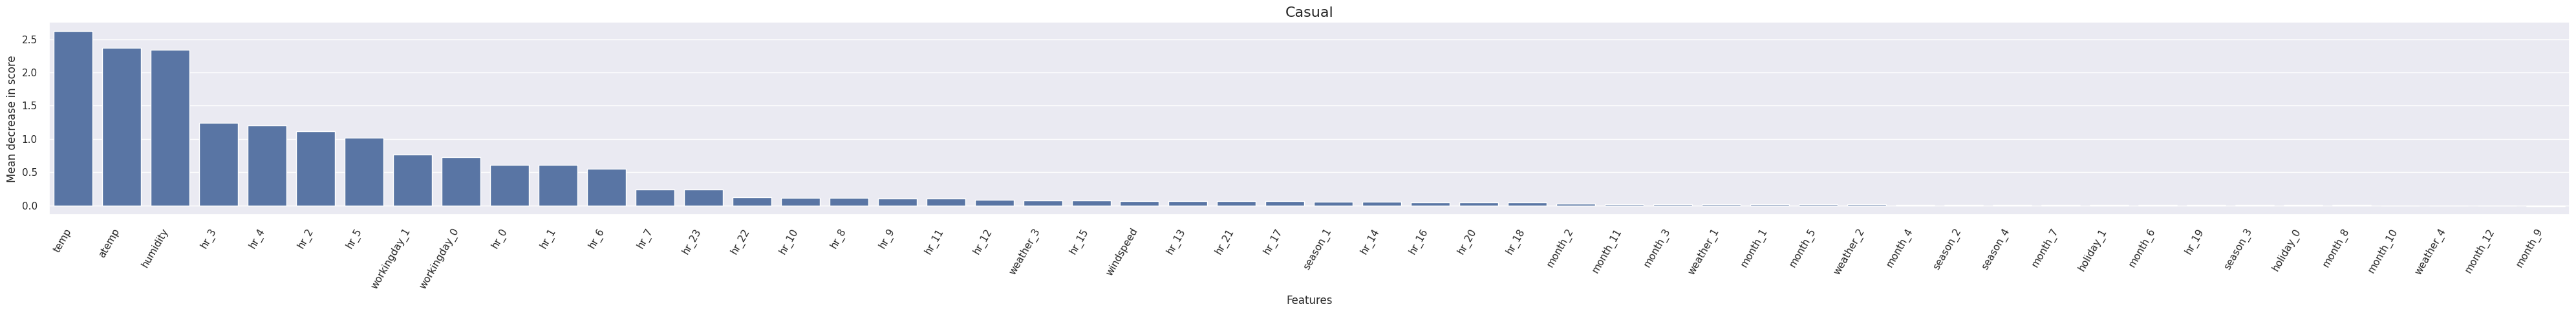

In [68]:
# Create a single matplotlib figure and axes (common convention: fig, ax)
fig, ax = plt.subplots(1, 1, figsize=(40, 5))

# Bar plot of permutation importances for 'casual_t'
# - x: feature names ('labels')
# - y: mean importance ('imp_score')
sns.barplot(
    x=df_feat_imp_casual_t['labels'],
    y=df_feat_imp_casual_t['imp_score'],
    orient='v',
    ax=ax
)

# Title and axis labels
ax.set_title("Casual", fontsize=16)

# By default, sklearn.permutation_importance uses the estimator's
ax.set_ylabel("Mean decrease in score", fontsize=12)
ax.set_xlabel("Features", fontsize=12)

# Rotate x-tick labels so long feature names are readable
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'decrease in Mean score')

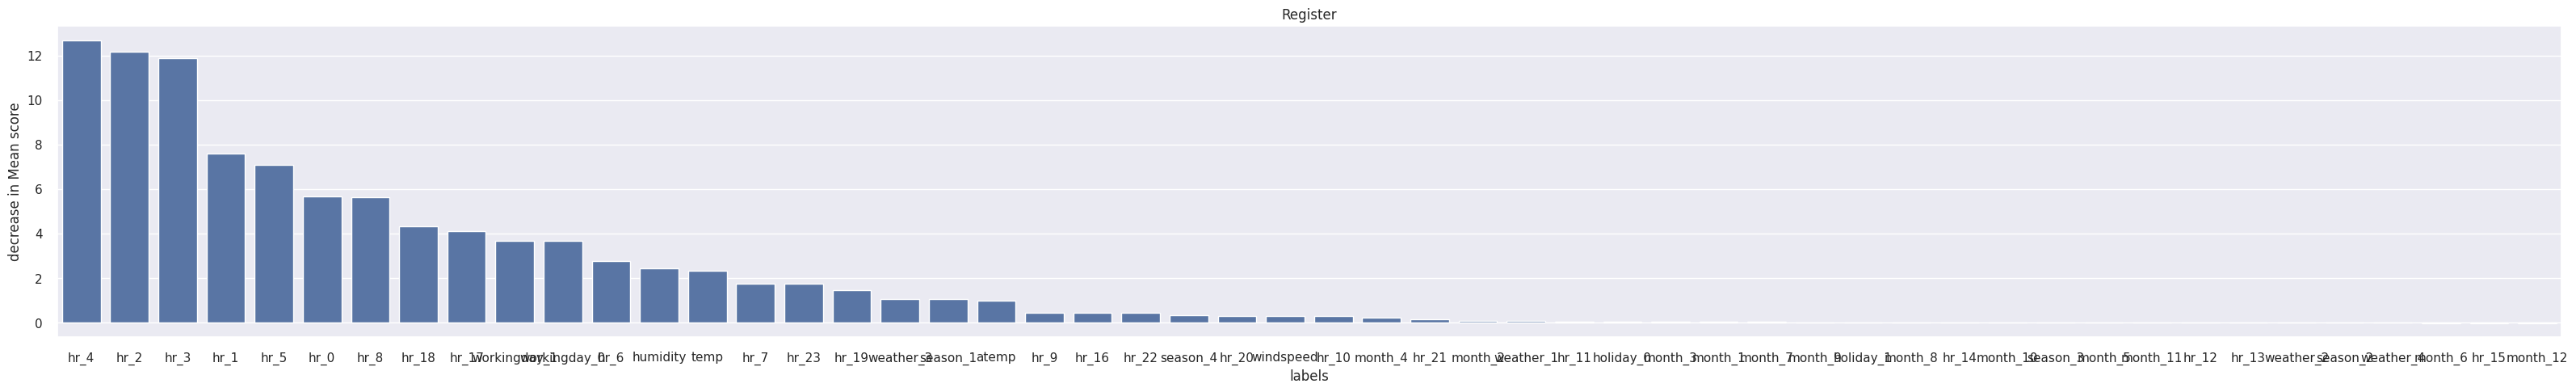

In [66]:
# for regitered_t
figure, axis = plt.subplots(1, 1,figsize=(40,5))
sns.barplot(x=df_feat_imp_register_t['labels'],y=df_feat_imp_register_t['imp_score'],orient='v')
plt.title("Register")
plt.ylabel('decrease in Mean score')

Text(0, 0.5, 'decrease in Mean score')

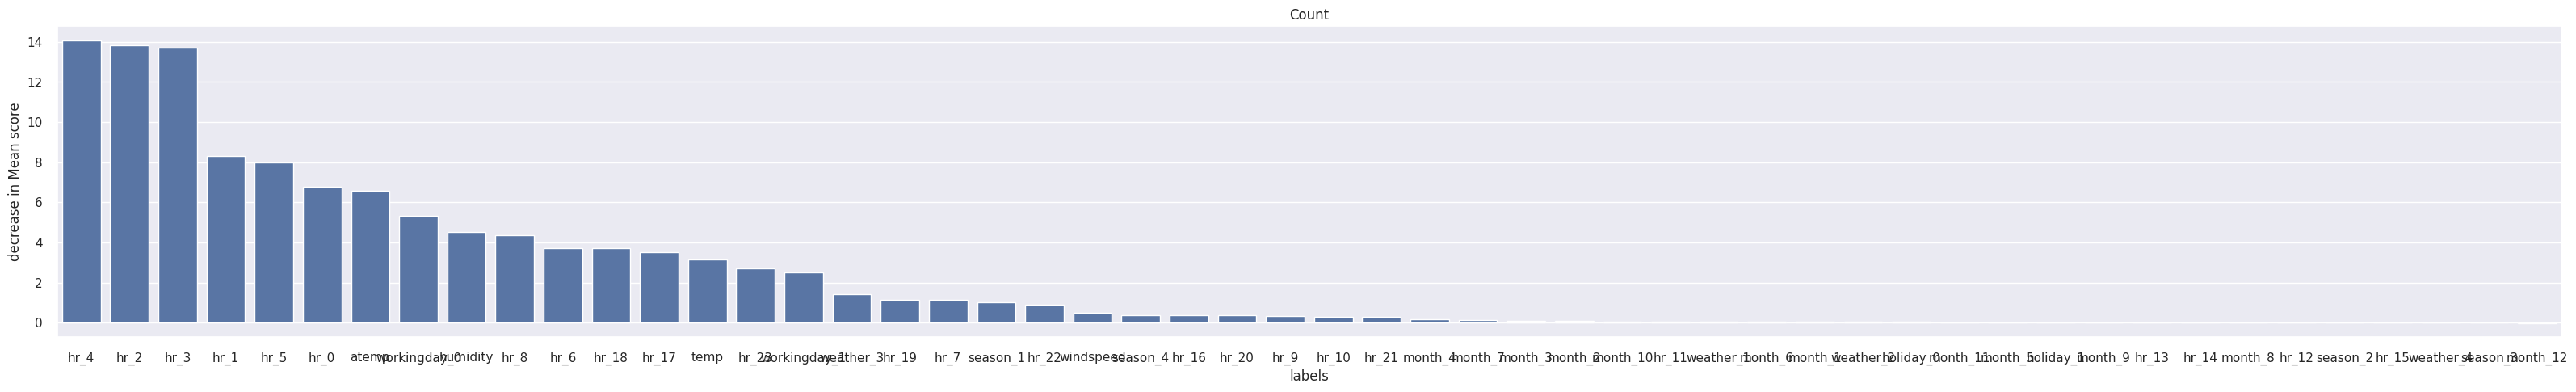

In [67]:
# for count_t
figure, axis = plt.subplots(1, 1,figsize=(40,5))
sns.barplot(x=df_feat_imp_count_t['labels'],y=df_feat_imp_count_t['imp_score'],orient='v')
plt.title("Count")
plt.ylabel('decrease in Mean score')

In [59]:
def cross_validation_rf(model, _X, _y, _cv, tar_cols, selected_feat, features_need_to_standardize):
    """
    Cross-validate a (tree-based) model per target using a preselected feature set per target.
    Scales only the designated numeric features (inside each fold) to avoid leakage.

    Parameters
    ----------
    model : estimator
        sklearn-like regressor with .fit() / .predict().
    _X : pd.DataFrame
        Feature matrix (same columns for all targets).
    _y : pd.DataFrame
        DataFrame containing all target columns listed in `tar_cols`.
    _cv : int
        Number of KFold splits.
    tar_cols : list[str]
        Target columns to iterate over (e.g., ['casual_t','registered_t','count_t']).
    selected_feat : dict[str, list[str]]
        Mapping from target name -> list of selected feature names to train on.
    features_need_to_standardize : list[str]
        Numeric feature names to scale (if present in the selected features for a given target).

    Returns
    -------
    res_scores : list[dict]
        One dict per fold * per target containing metrics.
    fold_coord : list[tuple]
        List of (train_index, test_index) per fold for traceability.
    """

    res_scores = []
    kf = KFold(n_splits=_cv)
    fold_coord = []

    for train_index, test_index in kf.split(_X, _y):
        # Slice per-fold data
        training_data = _X.iloc[train_index].copy()
        validation_data = _X.iloc[test_index].copy()
        fold_coord.append((train_index, test_index))

        # Fit/predict per target
        for tar in tar_cols:
            # Determine which of the "to-scale" features are actually in the selected feature set for this target.
            to_scale = list(set(features_need_to_standardize).intersection(selected_feat[tar]))

            # Fit scaler on TRAIN-only, then transform VALIDATION (prevents leakage).
            if len(to_scale) > 0:
                scaler = MinMaxScaler()
                training_data[to_scale] = scaler.fit_transform(training_data[to_scale])
                validation_data[to_scale] = scaler.transform(validation_data[to_scale])

            # Extract labels for this target (2D frame is fine for most regressors)
            training_label = _y[[tar]].iloc[train_index]
            validation_label = _y[[tar]].iloc[test_index]

            # Fit using only the preselected features for this target
            model.fit(training_data[selected_feat[tar]], training_label)

            # Predictions for validation and training (for both scores)
            validation_predict = model.predict(validation_data[selected_feat[tar]])
            training_predict = model.predict(training_data[selected_feat[tar]])

            # Append metrics
            res_scores.append({
                "Training R2": r2_score(training_label, training_predict),
                "Training _mean_squared_error": mean_squared_error(training_label, training_predict),
                "Training _root_mean_squared_error": np.sqrt(
                    mean_squared_error(training_label, training_predict)
                ),
                "Testing R2": r2_score(validation_label, validation_predict),
                "Testing _mean_squared_error": mean_squared_error(validation_label, validation_predict),
                "Testing _root_mean_squared_error": np.sqrt(
                    mean_squared_error(validation_label, validation_predict)
                ),
                "type_of_model": tar
            })

    return res_scores, fold_coord

In [60]:
selected_feat

{'casual_t': ['temp',
  'atemp',
  'humidity',
  'hr_3',
  'hr_4',
  'hr_2',
  'hr_5',
  'workingday_1',
  'workingday_0',
  'hr_0',
  'hr_1',
  'hr_6',
  'hr_7',
  'hr_23',
  'hr_22',
  'hr_10',
  'hr_8',
  'hr_9',
  'hr_11',
  'hr_12',
  'weather_3',
  'hr_15',
  'windspeed',
  'hr_13',
  'hr_21',
  'hr_17',
  'season_1',
  'hr_14',
  'hr_16',
  'hr_20',
  'hr_18',
  'month_2',
  'month_11',
  'month_3',
  'weather_1',
  'month_1',
  'month_5',
  'weather_2',
  'month_4',
  'season_2',
  'season_4',
  'month_7',
  'holiday_1',
  'month_6',
  'hr_19',
  'season_3',
  'holiday_0',
  'month_8',
  'month_10'],
 'registered_t': ['hr_4',
  'hr_2',
  'hr_3',
  'hr_1',
  'hr_5',
  'hr_0',
  'hr_8',
  'hr_18',
  'hr_17',
  'workingday_1',
  'workingday_0',
  'hr_6',
  'humidity',
  'temp',
  'hr_7',
  'hr_23',
  'hr_19',
  'weather_3',
  'season_1',
  'atemp',
  'hr_9',
  'hr_16',
  'hr_22',
  'season_4',
  'hr_20',
  'windspeed',
  'hr_10',
  'month_4',
  'hr_21',
  'month_2',
  'weather_1',

In [61]:
tar_cols=['casual_t','registered_t','count_t']
features_need_to_standardize=['temp','atemp', 'humidity','windspeed']
Rr_result,fold_cord=cross_validation_rf(reg_tree, X, y, 5,tar_cols,selected_feat,features_need_to_standardize)
Rr_result=pd.DataFrame(Rr_result)
Rr_result

,Training R2,Training _mean_squared_error,Training _root_mean_squared_error,Testing R2,Testing _mean_squared_error,Testing _root_mean_squared_error,type_of_model
0,0.981232,0.233478,0.483195,0.858360,1.723671,1.312886,casual_t
1,0.984409,0.874312,0.935047,0.892225,6.103899,2.470607,registered_t
2,0.984248,1.057285,1.028243,0.890347,7.391094,2.718657,count_t
3,0.979808,0.249399,0.499398,0.876315,1.549122,1.244637,casual_t
4,0.984442,0.873349,0.934531,0.886427,6.407553,2.531314,registered_t
5,0.984485,1.040910,1.020250,0.892738,7.245285,2.691707,count_t
6,0.980954,0.237751,0.487597,0.860996,1.668631,1.291755,casual_t
7,0.984479,0.875347,0.935600,0.886799,6.269054,2.503808,registered_t
8,0.984090,1.073638,1.036165,0.885231,7.574124,2.752113,count_t
9,0.980435,0.239078,0.488956,0.853917,1.907165,1.381001,casual_t


In [62]:
# Feature subset selected for the 'count_t' target (from your earlier feature selection step)
selected_feat_count = selected_feat['count_t']

# Define a (small) grid of hyperparameters to search for RandomForestRegressor.

param_distributions = {
    "n_estimators": [50,500,1000],
    "max_depth":    [None, 12]
}

# Base RF with a fixed random_state for reproducibility
reg_rff = RandomForestRegressor(random_state=42)

# Grid search over the specified parameter grid.
# - By default, cv=5 .
clf = GridSearchCV(reg_rff, param_distributions,scoring='neg_mean_squared_error')

scaler = MinMaxScaler()
df_transform[selected_feat_count] = scaler.fit_transform(df_transform[selected_feat_count])

# Fit on the selected features and the transformed target 'count_t'.
clf.fit(df_transform[selected_feat_count], df_transform[['count_t']])

GridSearchCV(estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 12],
                         'n_estimators': [50, 500, 1000]},
             scoring='neg_mean_squared_error')

In [63]:
print("\n The best estimator across ALL searched params:\n",clf.best_estimator_)
print("\n The best score across ALL searched params:\n",clf.best_score_)
print("\n The best parameters across ALL searched params:\n",clf.best_params_)


 The best estimator across ALL searched params:
 RandomForestRegressor(n_estimators=1000, random_state=42)

 The best score across ALL searched params:
 -7.474069593255879

 The best parameters across ALL searched params:
 {'max_depth': None, 'n_estimators': 1000}


## Model optimization summary


From the baseline experiments, **RandomForestRegressor** was selected because it delivered **better validation performance than Linear Regression** and **performance comparable to XGBRegressor**, while generally more straightforward to interpret/tune than XGBoost.

---

### Feature selection via permutation importance (MSE-based)
To tailor the input space to each prediction target, **permutation importance** was computed **with `scoring='neg_mean_squared_error'`**, so that importances reflect the **average change in MSE** when a feature’s values are randomly permuted:

- For each transformed target (`casual_t`, `registered_t`, `count_t`), the model was trained and then each feature was permuted multiple times.
- The **mean decrease in performance** (equivalently, the **mean increase in MSE**) defines a feature’s importance.
- **Features with non-positive mean importance** (≤ 0 change) were **excluded** from that target’s feature set.
- The selected features were then **validated across 5-fold CV** to confirm **stable performance** (i.e., similar metrics across folds), ensuring the pruning did not introduce variability or degrade generalization.

---

### Hyperparameter optimization strategy
Hyperparameter tuning was performed **after** feature selection. To keep compute tractable:

- Tuning was run **only for the `count_t` target**, and the resulting settings were **reused** for `casual_t` and `registered_t`.  
  - This is a practical compromise because full per-target tuning can be **computationally expensive**.  
  - In practice, per-target tuning may yield incremental gains; reusing the “count_t” settings is reasonable for a baseline.

- A compact **GridSearchCV** (cross-validated) was used over a **small set of parameters** to **demonstrate the process**:
  - **`n_estimators`** (number of trees) and **`max_depth`** (maximum tree depth).
  - Although Random Forest exposes more hyperparameters, optimizing these two provides most of the **bias–variance control** with minimal search cost.

---

### Key RandomForestRegressor hyperparameters (scikit-learn)

Below are the most impactful knobs, with what they do and typical ranges to consider (for future, more thorough tuning):

- **`n_estimators`** *(int)* — number of trees in the forest.  
  More trees ↓ variance (better stability) but ↑ compute.  
  *Typical baselines:* `200–1000`.

- **`max_depth`** *(int or None)* — maximum depth of each tree.  
  Limits model complexity; smaller values ↑ bias, ↓ variance.  
  *Try:* `None, 8, 12, 16, 20, 24`.

- **`min_samples_split`** *(int or float)* — minimum samples required to split an internal node.  
  Larger values regularize by preventing deep, narrow splits.  
  *Try:* `2, 5, 10, 20, 40`.

- **`min_samples_leaf`** *(int or float)* — minimum samples required at a leaf node.  
  Strong effect on smoothing predictions; values ≥ 2 often stabilize.  
  *Try:* `1, 2, 4, 8, 12`.

- **`max_features`** *({"sqrt","log2"} or float or int)* — subset of features to consider at each split.  
  Lower fractions ↑ tree diversity and often help generalization.  
  *Try:* `0.3, 0.5, 0.7, "sqrt"`.

- **`bootstrap`** *(bool)* and **`max_samples`** *(float or int)* — sampling strategy per tree.  
  With `bootstrap=True`, `max_samples<1.0` reduces correlation among trees.

- **`criterion`** *({"squared_error","absolute_error"})* — split impurity measure.  
  `squared_error` aligns with RMSE/MSE; `absolute_error` can be more robust to outliers.

- **`oob_score`** *(bool)* — out-of-bag score for a quick internal generalization estimate (requires `bootstrap=True`).

- **`random_state`, `n_jobs`** — reproducibility and parallelism.

For this project’s **demonstration baseline**, the grid focused on **`n_estimators`** and **`max_depth`**. Future optimization can broaden the search to include **`min_samples_leaf`**, **`min_samples_split`**, and **`max_features`** for finer bias–variance control.

---

### Outcome
After pruning features by **MSE-based permutation importance** and tuning a **compact grid** on `count_t`, the same configuration is **applied to the other targets** this is just for simplification purposes and for each target a different model with **expanded hyperparameter spaces** and **per-target tuning** is needed.


# Part 4: Results

In [69]:
def model_fit(x_train,x_test,y_train,y_test,model,selected_feat,tar_cols):
  res_scores=[]
  Predictions=pd.DataFrame()
  for tar in tar_cols:

    scaler = MinMaxScaler()
    x_train[features_need_to_standardize] = scaler.fit_transform(
           x_train[features_need_to_standardize]
        )
    x_test[features_need_to_standardize] = scaler.transform(
            x_test[features_need_to_standardize]
        )

    reg=model.fit(x_train[selected_feat[tar]],y_train[[tar]])
    training_predict=reg.predict(x_train[selected_feat[tar]])
    y_predict = reg.predict(x_test[selected_feat[tar]])


    #y_predict = [item for sublist in y_predict for item in sublist]

    if any(x<0 for x in y_predict) == False:

      res_scores.append({"Training R2":  r2_score(y_train[[tar]], training_predict),
                    "Training _mean_squared_error": mean_squared_error(y_train[[tar]], training_predict),
                    "Training _root_mean_squared_error": np.sqrt(mean_squared_error(y_train[[tar]], training_predict)),
                    "Traning_RMSLE":np.sqrt(mean_squared_log_error(y_train[[tar]], training_predict)),
                    "Testing R2": r2_score(y_test[[tar]], y_predict),
                    "Testing _mean_squared_error":mean_squared_error(y_test[[tar]], y_predict),
                    "Testing _root_mean_squared_error":  np.sqrt(mean_squared_error(y_test[[tar]], y_predict)),
                    "Testing_RMSLE":np.sqrt(mean_squared_log_error(y_test[[tar]], y_predict)),
                    "type_of_model":tar

                    })
    else:
          res_scores.append({"Training R2":  r2_score(y_train[[tar]], training_predict),
                  "Training _mean_squared_error": mean_squared_error(y_train[[tar]], training_predict),
                  "Training _root_mean_squared_error": np.sqrt(mean_squared_error(y_train[[tar]], training_predict)),
                  "Testing R2": r2_score(y_test[[tar]], y_predict),
                  "Testing _mean_squared_error":mean_squared_error(y_test[[tar]], y_predict),
                  "Testing _root_mean_squared_error":  np.sqrt(mean_squared_error(y_test[[tar]], y_predict)),
                  "type_of_model":tar

                  })
    Predictions[tar+'pred']=y_predict




  return Predictions,pd.DataFrame(res_scores)

In [70]:
reg_tree = RandomForestRegressor(n_estimators = 1000)
Predictions,result_rf= model_fit(x_train,x_test,y_train,y_test,reg_tree,selected_feat,tar_cols)

In [71]:
def evalu(name, Predictions, y_test):
    """
    Evaluate predictions by:
      - inverse-transforming Box–Cox targets back to original units,
      - constructing 'count' predictions as casual + registered,
      - plotting predicted vs actual, residuals, and residual distribution,
      - returning a joined evaluation DataFrame.

    Parameters
    ----------
    name : str
        Label for this evaluation run (used only in print).
    Predictions : pd.DataFrame
        Must contain columns:
          - 'casual_tpred'      (predictions on the transformed scale)
          - 'registered_tpred'  (predictions on the transformed scale)
        NOTE: function computes corresponding inverse-transformed predictions.
    y_test : pd.DataFrame
        Must contain the true targets in original units, at least:
          - 'count' (and, optionally, 'casual', 'registered' if you want to inspect those too)

    Returns
    -------
    eval_df : pd.DataFrame
        Concatenation of y_test and Predictions, including derived columns.
    """

    print("analysis for ", name)

    # Align indices so rows match before concatenation.
    y_test.reset_index(drop=True, inplace=True)
    Predictions.reset_index(drop=True, inplace=True)

    # Inverse Box–Cox back to original units.
    # IMPORTANT: Use the SAME lambdas that were used to forward-transform during training.
    Predictions['casual_pred'] = inv_boxcox1p(Predictions['casual_tpred'], 0.3)
    Predictions['registered_pred'] = inv_boxcox1p(Predictions['registered_tpred'], 0.4)

    # Construct total count prediction as sum of components (casual + registered).
    # This ensures additivity on the ORIGINAL scale.
    Predictions['count_realpred'] = Predictions['casual_pred'] + Predictions['registered_pred']

    Predictions['residual'] = np.sqrt((Predictions['count_realpred'] - y_test['count'])**2)

    # Combine ground truth and predictions side-by-side for inspection.
    eval_df = pd.concat([y_test, Predictions], axis=1)

    # --- Plots ---
    figure, axis = plt.subplots(1, 3, figsize=(40, 5))

    # 1) Predicted vs Actual scatter for total count
    sns.scatterplot(x=eval_df["count_realpred"], y=eval_df['count'], ax=axis[0])
    axis[0].set_title("Predicted vs Actual (count)")
    axis[0].set_xlabel("Predicted count")
    axis[0].set_ylabel("Actual count")

    # 2) Residuals vs Predicted (helps assess heteroscedasticity / patterns)
    sns.scatterplot(
        x=eval_df["count_realpred"],
        y=eval_df['count'] - eval_df['count_realpred'],
        ax=axis[1]
    )
    axis[1].axhline(0.0, color='k', linewidth=1)
    axis[1].set_title("Residuals vs Predicted")
    axis[1].set_xlabel("Predicted count")
    axis[1].set_ylabel("Residual (Actual - Predicted)")

    # 3) Residual distribution
    sns.distplot(eval_df['count'] - eval_df['count_realpred'], ax=axis[2])
    axis[2].set_title("Residual Distribution")
    axis[2].set_xlabel("Residual (Actual - Predicted)")
    axis[2].set_ylabel("Density")

    return eval_df

analysis for  reg_tree


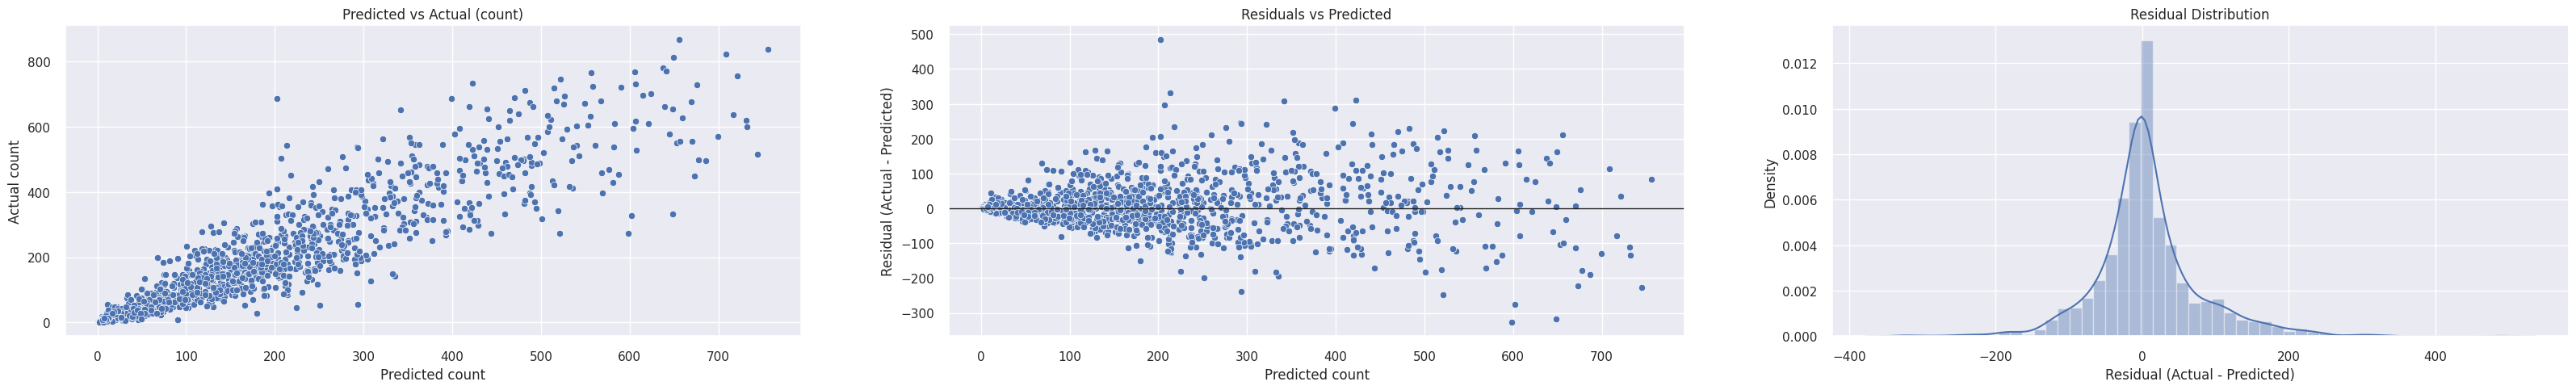

In [72]:
eval_df=evalu("reg_tree",Predictions,y_test)

In [73]:
eval_df.describe()

,casual,registered,count,casual_t,registered_t,count_t,casual_tpred,registered_tpred,count_tpred,casual_pred,registered_pred,count_realpred,residual
count,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000
mean,36.112471,155.707728,191.820199,5.014609,14.109166,15.533431,5.058530,14.109397,15.550712,34.216962,150.592846,184.809808,46.939552
std,49.188783,149.702478,179.515898,3.462176,7.455080,8.138081,3.204088,7.022566,7.639251,43.596220,135.702175,162.213334,54.622154
min,0.000000,1.000000,1.000000,0.000000,0.798770,0.798770,0.002311,0.701379,1.199171,0.002313,0.855636,1.384120,0.001516
25%,4.000000,38.000000,45.500000,2.068855,8.323453,9.112218,2.420781,8.771737,9.637204,5.170693,42.164544,50.321406,8.162805
50%,18.000000,117.000000,147.000000,4.729818,14.353605,15.952053,4.683854,14.846900,16.243736,17.641362,125.824946,149.131512,27.661932
75%,49.000000,225.000000,279.500000,7.445450,19.356639,21.329394,7.423147,18.709826,20.739148,48.655979,208.648972,262.941617,65.768974
max,357.000000,745.000000,868.000000,16.122223,32.739971,34.958288,15.012724,31.577703,33.475453,293.360793,685.002600,755.862025,484.717180


In [74]:
result_rf

,Training R2,Training _mean_squared_error,Training _root_mean_squared_error,Traning_RMSLE,Testing R2,Testing _mean_squared_error,Testing _root_mean_squared_error,Testing_RMSLE,type_of_model
0,0.981698,0.228020,0.477515,0.143396,0.854363,1.744370,1.320746,0.313802,casual_t
1,0.985058,0.841380,0.917268,0.086826,0.890577,6.076905,2.465138,0.194297,registered_t
2,0.984962,1.012927,1.006443,0.087306,0.889051,7.342363,2.709679,0.199339,count_t


In [75]:
Predictions

,casual_tpred,registered_tpred,count_tpred,casual_pred,registered_pred,count_realpred,residual
0,0.705865,6.173158,6.116828,0.896945,21.417806,22.314750,6.685250
1,5.237057,27.597146,28.352645,22.284817,501.878722,524.163539,37.836461
2,3.692444,9.822269,11.073177,11.005642,52.935745,63.941387,9.941387
3,9.028844,17.554776,20.682711,77.956419,181.261330,259.217750,26.782250
4,3.140465,13.083194,14.205435,8.139761,96.004336,104.144097,11.855903
...,...,...,...,...,...,...,...
1302,8.966454,18.705709,21.528955,76.635947,208.547248,285.183195,44.816805
1303,0.262770,6.909344,7.351950,0.287789,26.481998,26.769787,11.769787
1304,6.593791,20.095856,19.462036,37.002813,244.596378,281.599191,68.599191
1305,6.696460,19.399635,20.598269,38.328803,226.113097,264.441900,70.558100


In [76]:
y_test

,casual,registered,count,casual_t,registered_t,count_t
0,2,27,29,1.301297,6.979888,7.245150
1,26,536,562,5.626251,28.397954,28.987876
2,7,47,54,2.886887,9.260790,9.918956
3,56,230,286,7.877585,19.548792,21.548764
4,13,103,116,4.023944,13.523351,14.296328
...,...,...,...,...,...,...
1302,59,271,330,8.051433,21.037892,22.960751
1303,1,14,15,0.770481,4.885442,5.078583
1304,37,176,213,6.593571,17.321171,18.884816
1305,50,285,335,7.509675,21.515212,23.113901


Text(0, 0.5, 'Count')

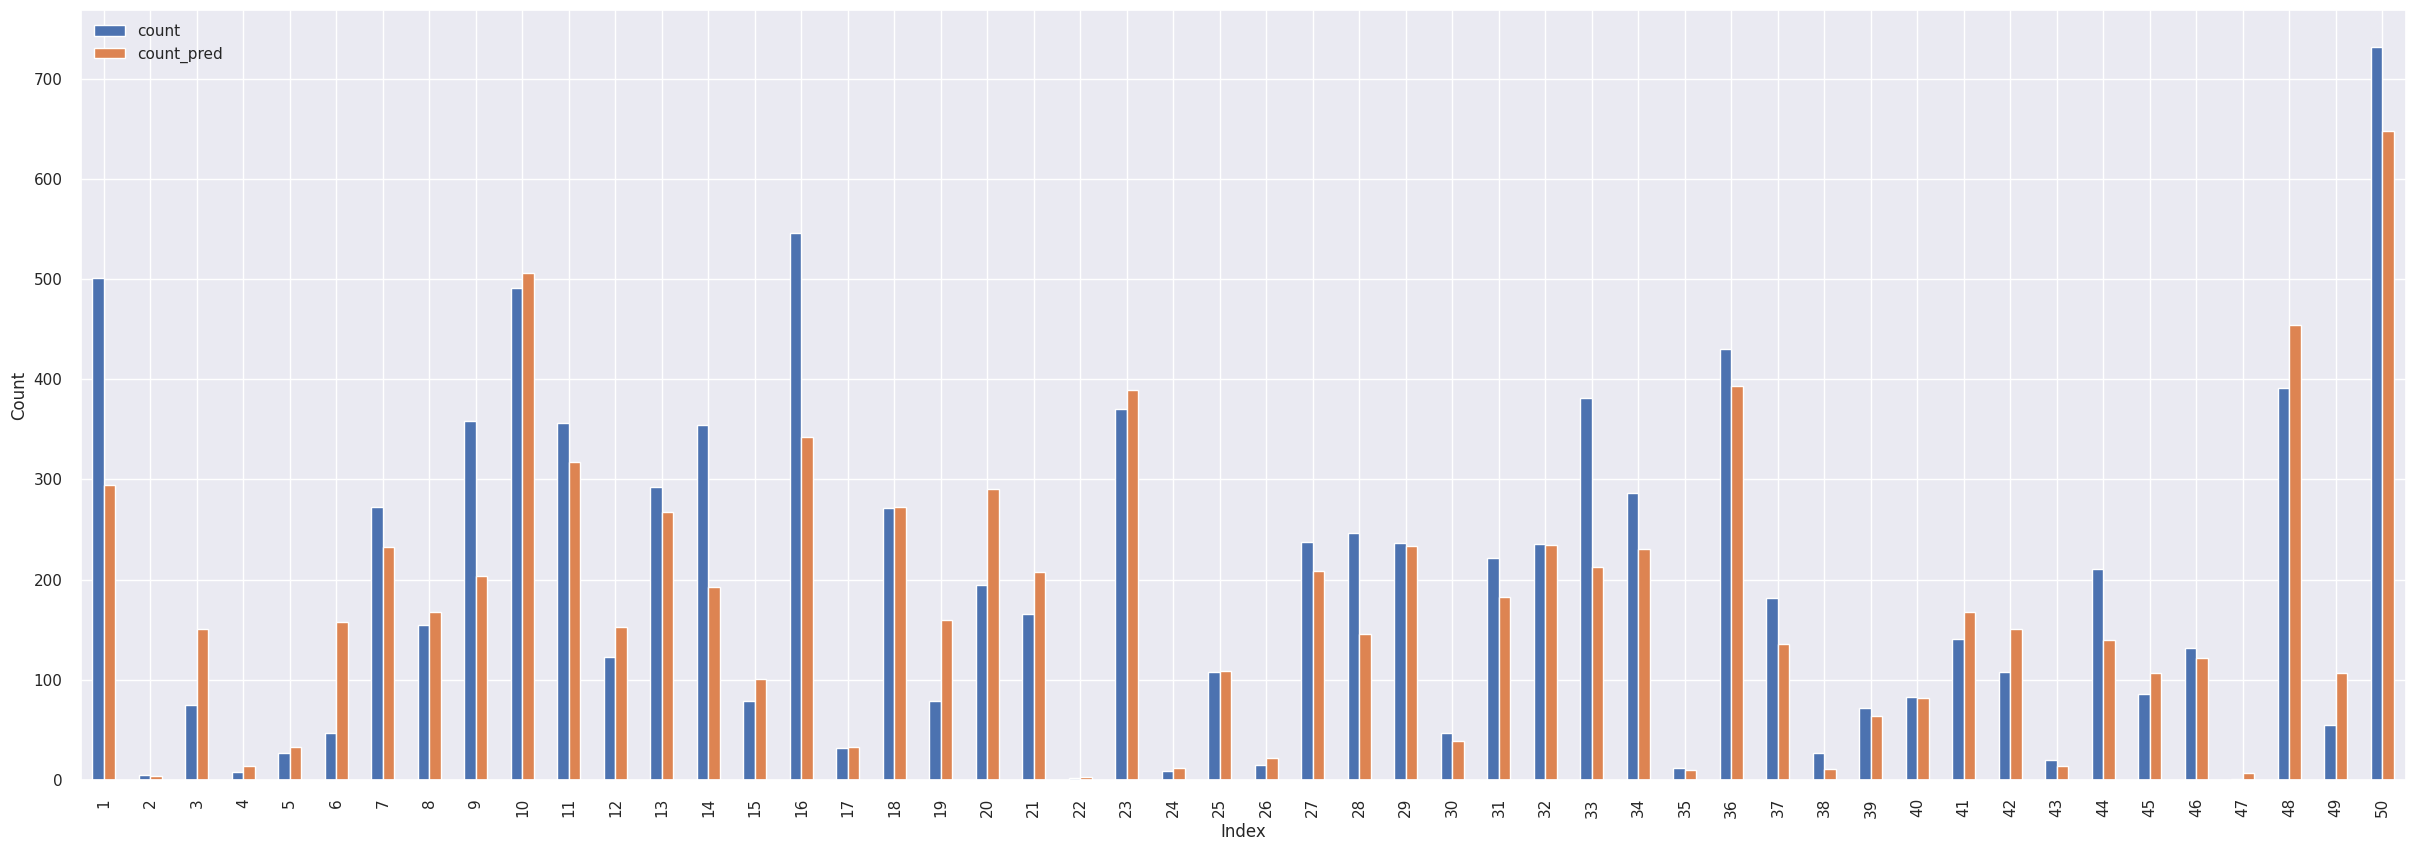

In [77]:
df_pred_test = pd.DataFrame()

df_pred_test['casual_pred'] = Predictions['casual_pred'].round(0)
df_pred_test['registered_pred'] = Predictions['registered_pred'].round(0)
df_pred_test['count_pred'] = inv_boxcox1p(Predictions['count_tpred'],0.4).round(0)
df_pred_test['count_pred_rc'] = Predictions['casual_pred'].round(0) + Predictions['registered_pred'].round(0)

df_pred_test['casual'] = y_test['casual']
df_pred_test['registered'] = y_test['registered']
df_pred_test['count'] = y_test['count']

df_pred_test_sample = df_pred_test.sample(n=50,random_state=42).reset_index(drop=True)

df_graph = df_pred_test_sample.copy()
df_graph['index']=np.linspace(1,50).astype(int)
ax=df_graph.plot(x='index',y=['count','count_pred'],kind='bar',figsize=(30, 10))
ax.set_xlabel("Index")
ax.set_ylabel("Count")

In [78]:
np.sqrt(mean_squared_error(df_pred_test["count_pred_rc"], df_pred_test["count"]))

np.float64(72.01399379439263)

## Results Summary


### Procedure
After feature selection (MSE-based permutation importance) and hyperparameter tuning, the final RandomForestRegressor configuration was trained. Because the external test set was unavailable, a hold-out test split was carved from the training data. Two models were fit—one for `casual_t` and one for `registered_t`—their predictions were inverse-transformed to original units and **summed** to obtain `count_pred_rc`.

Ideally, the final score should come from an **out-of-sample** set **not** used for feature selection or tuning. Here, the carved-out split was involved in the process, so results are **indicative** rather than definitive.

### Test performance (carved-out split)
- **RMSE (count)**: **72**  
  This means the model’s predictions for hourly total demand are off by **~72 rentals on average** (root-mean-square sense).


### Takeaways
- The tuned Random Forest demonstrates meaningful skill on the carved-out split (RMSE = 72).
- A final assessment should be repeated on a **true held-out**  dataset to remove.

## Part 5: Labeling test set and Conclusion

In [81]:
df_train = pd.read_csv("/content/drive/MyDrive/CSCA_5622_Final_Project/Bicycle_demand_modeling/training_data.csv")
df_train['datetime']=pd.to_datetime(df_train['datetime'])
df_train['hr']= df_train.datetime.dt.hour
df_train['month'] = df_train.datetime.dt.month

features_need_to_standardize = ['temp', 'atemp', 'humidity', 'windspeed']
df_train['casual_t'] = boxcox1p(df_train['casual'],0.3)
df_train['registered_t'] = boxcox1p(df_train['registered'],0.4)

selected_feat_casual = selected_feat['casual_t']
selected_feat_registered = selected_feat['registered_t']

df_train = pd.get_dummies(data = df_train, columns=['season', 'holiday','workingday','weather','hr','month'])
df_train.drop(columns=['Unnamed: 0','datetime'],inplace=True)

scaler = MinMaxScaler()
df_train[features_need_to_standardize] = scaler.fit_transform(df_train[features_need_to_standardize])

df_test = pd.read_csv("/content/drive/MyDrive/CSCA_5622_Final_Project/Bicycle_demand_modeling/test_data.csv")
df_test['datetime']=pd.to_datetime(df_test['datetime'])
df_test['hr']= df_test.datetime.dt.hour
df_test['month'] = df_test.datetime.dt.month

df_test[features_need_to_standardize] = scaler.transform(df_test[features_need_to_standardize])
df_test = pd.get_dummies(data=df_test, columns=['season', 'holiday','workingday','weather','hr','month'])

df_train_casual = df_train.copy()
df_train_register = df_train.copy()
df_test_casual = df_test.copy()
df_test_register = df_test.copy()

df_train_casual = df_train_casual[selected_feat_casual]
df_test_casual = df_test_casual[selected_feat_casual]

df_train_register = df_train_register[selected_feat_registered]
df_test_register = df_test_register[selected_feat_registered]

reg_tree = RandomForestRegressor(n_estimators = 1000)
reg_tree.fit(df_train_casual,df_train['casual_t'])

y_casual_t_pred = reg_tree.predict(df_test_casual)
casual_pred = inv_boxcox1p(y_casual_t_pred,0.3)

reg_tree.fit(df_train_register,df_train['registered_t'])

y_register_t_pred = reg_tree.predict(df_test_register)
register_pred = inv_boxcox1p(y_casual_t_pred,0.4)

count = register_pred.round(0) + casual_pred.round(0)

df_test = pd.read_csv("/content/drive/MyDrive/CSCA_5622_Final_Project/Bicycle_demand_modeling/test_data.csv")

df_test['casual'] = casual_pred.round(0)
df_test['registered'] = register_pred.round(0)
df_test['count'] = count.round(0)

df_test.to_csv("/content/drive/MyDrive/CSCA_5622_Final_Project/Bicycle_demand_modeling/result_test_data.csv")

In [83]:
df_test.head()

,Unnamed: 0,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,6715,2012-03-17 02:00:00,1,0,0,2,18.04,21.970,88,0.0000,19.0,14.0,33.0
1,6413,2012-03-04 11:00:00,1,0,0,1,13.12,14.395,45,26.0027,38.0,25.0,63.0
2,4273,2011-10-10 02:00:00,4,1,0,1,19.68,23.485,88,0.0000,15.0,12.0,27.0
3,6538,2012-03-09 16:00:00,1,0,1,1,19.68,23.485,23,27.9993,26.0,18.0,44.0
4,7777,2012-06-04 10:00:00,2,0,1,1,26.24,31.060,41,31.0009,47.0,30.0,77.0


# Discussion and Conclusion

### What this project demonstrates
This work walked through the **end-to-end supervised modeling cycle**: data cleaning, exploratory analysis, feature engineering, model selection, feature selection, and hyperparameter optimization. The problem was clearly framed as **missing-value imputation (interpolation)** for hourly bike demand, not future **demand forecasting**. Consequently, the modeling design allowed using both **past and future timestamps** within the historical window (while avoiding target leakage). If the objective had been forecasting, a **time-ordered** training/validation scheme (rolling/blocked CV) would have been required to prevent future→past leakage.

### Summary of results
- **Model choice:** RandomForestRegressor was selected as the baseline winner (comparable validation performance to XGBoost; stronger than Linear Regression), with the added benefits of simpler configuration and straightforward interpretability (e.g., permutation importance).
- **Feature selection:** Permutation importance (MSE-based) was used per target, retaining features that yielded a positive mean decrease in error.
- **Performance:** On the carved-out holdout split, the model achieved **RMSE ≈ 72** (original units) and **R² in the high 0.8s**, indicating substantial predictive skill versus a naive mean baseline. Performance was **consistent across folds**.
- **Error characteristics:** Residuals were generally centered near zero with an approximately normal shape; however, **errors increased for high-demand hours**. This suggests the model lacks predictors that explain **spikes** (e.g., events, special promotions, anomalies in traffic/transit/holidays/weather extremes).

> **Evaluation caveat:** Because the external labeled test set was unavailable, the carved-out split was also used during selection/tuning at times, which can introduce **optimism**. Final conclusions should be confirmed on a **strictly held-out (preferably out-of-time)** test set not used in feature selection or hyperparameter optimization.

### Limitations and opportunities for improvement
1. **Feature space**
   - Current features are primarily **meteorological/time** signals (`temp`, `atemp`, `humidity`, `windspeed`, hour, month, season, holiday, weather).
   - High-demand spikes are likely driven by **exogenous factors** not yet captured:
     - **Events** (concerts, sports, festivals), **school/work calendars**, **transit outages**, **pricing/promotions**, **competitor availability**, **road works**, **tourism/footfall indices**.
   - Enriching with these features should improve peak prediction and reduce RMSE.

2. **Transformations and preprocessing**
   - Targets were stabilized via **Box–Cox (`boxcox1p`, λ=0.4)**; **numeric features** were **Min–Max scaled** inside CV to avoid leakage.
   - Further **feature transformations** (e.g., log/quantile or Yeo–Johnson where appropriate) could better align linear-model assumptions and sometimes help tree methods in the presence of heavy tails or heteroscedasticity.

3. **Modeling breadth**
   - Three models were evaluated (OLS, RF, XGB). Additional baselines could be explored:
     - **Regularized linear models** (Ridge/Lasso/Elastic Net), **polynomial features** (with strong regularization to prevent overfit), **SVR** (with RBF kernel), and **GBDT variants** (LightGBM/CatBoost).
   - These may capture different bias–variance trade-offs and interactions.

4. **Hyperparameter optimization**
   - For demonstration, tuning focused on **`n_estimators`** and **`max_depth`** (on `count_t`) and re-used for other targets.
   - A fuller search could include **`min_samples_leaf`**, **`min_samples_split`**, **`max_features`**, **`bootstrap/max_samples`**, and (for XGB) **`eta`**, **`subsample`**, **`colsample_bytree`**, **`min_child_weight`**.
   - The observed **train–validation gap** in the tree ensembles points to **variance/overfitting** (not bias); stronger regularization and more diverse features typically help.

### Conclusion
The project successfully demonstrates a complete supervised learning pipeline for **interpolating missing demand** values. The selected Random Forest baseline delivers **meaningful accuracy** (RMSE ≈ **72**, R² ≈ **0.8+**) and **stable cross-fold performance**, yet still misses some **peak-demand** behavior due to unmodeled exogenous drivers. The clearest paths to improved accuracy are:
- **Richer exogenous features** (events, promotions, transit/traffic, competitor signals),
- **Broader hyperparameter tuning** (stronger regularization in ensembles),
- **Expanded model families** (regularized linear, SVR, alternative GBDTs),
- And **evaluation on a strictly held-out/out-of-time set**.

These steps should reduce high-demand errors, narrow the generalization gap, and further lower RMSE while preserving interpretability and robustness.
